In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib import colors

from boostedhh import utils, hh_vars

In [ ]:
# automatically reloads imported files on edits
%load_ext autoreload
%autoreload 2

In [3]:
# base_dir = "/eos/uscms/store/user/adas1/bbtautau/skims/HHbbtt/2023/2025_06_19_17h07m09s_UTC"
base_dir = "/eos/uscms/store/user/adas1/bbtautau/skims/HHbbtt/2023/2025_06_23_16h45m40s_UTC"
df_orig = pd.read_parquet(
    base_dir + "/outparquet/"
)    

df = df_orig

In [4]:
#  B pparkign can nw go to 20 GeV

In [5]:
list(df.keys())

[('GenHiggsEta', 0),
 ('GenHiggsEta', 1),
 ('GenHiggsPhi', 0),
 ('GenHiggsPhi', 1),
 ('GenHiggsMass', 0),
 ('GenHiggsMass', 1),
 ('GenHiggsPt', 0),
 ('GenHiggsPt', 1),
 ('GenHiggsChildren', 0),
 ('GenHiggsChildren', 1),
 ('GenbbEta', 0),
 ('GenbbEta', 1),
 ('GenbbPhi', 0),
 ('GenbbPhi', 1),
 ('GenbbMass', 0),
 ('GenbbMass', 1),
 ('GenbbPt', 0),
 ('GenbbPt', 1),
 ('GenTauEta', 0),
 ('GenTauEta', 1),
 ('GenTauPhi', 0),
 ('GenTauPhi', 1),
 ('GenTauMass', 0),
 ('GenTauMass', 1),
 ('GenTauPt', 0),
 ('GenTauPt', 1),
 ('GenTauhh', 0),
 ('GenTauhm', 0),
 ('GenTauhe', 0),
 ('run', 0),
 ('event', 0),
 ('luminosityBlock', 0),
 ('ht', 0),
 ('nElectrons', 0),
 ('nMuons', 0),
 ('nTaus', 0),
 ('nBoostedTaus', 0),
 ('nJets', 0),
 ('nFatJets', 0),
 ('nPU', 0),
 ('nPV', 0),
 ('ElectronTrigMatchEGamma', 0),
 ('ElectronTrigMatchEGamma', 1),
 ('ElectronTrigMatchETau', 0),
 ('ElectronTrigMatchETau', 1),
 ('MuonTrigMatchMuon', 0),
 ('MuonTrigMatchMuon', 1),
 ('MuonTrigMatchMuonTau', 0),
 ('MuonTrigMatchMuonT

In [6]:
acc_cond = {
    'eta_tau': 2.5, 'pt_tau': 20, 
    'eta_bb': 2.5, 'pt_bb': 20,
    'eta_ak4': 2.5, 'pt_ak4': 20,
    'eta_ak8': 2.5, 'pt_ak8': 200
    }

acc_mask_tau = (
    (df[('GenTauPt',  0)] > acc_cond['pt_tau'])  &
    (np.abs(df[('GenTauEta', 0)]) < acc_cond['eta_tau']) &
    (df[('GenTauPt',  1)] > acc_cond['pt_tau'])  &
    (np.abs(df[('GenTauEta', 1)]) < acc_cond['eta_tau'])
)

acc_mask_bb = (
    (df[('GenbbPt',   0)] > acc_cond['pt_bb'])   &
    (np.abs(df[('GenbbEta', 0)]) < acc_cond['eta_bb']) &
    (df[('GenbbPt',   1)] > acc_cond['pt_bb'])   &
    (np.abs(df[('GenbbEta', 1)]) < acc_cond['eta_bb'])
)

# AK4 jets: require AT LEAST ONE jet to pass the cuts 
ak4_pt_cols  = [('ak4JetPt',  i)  for i in range(4)]
ak4_eta_cols = [('ak4JetEta', i)  for i in range(4)]
acc_mask_ak4 = (
    df[ak4_pt_cols].gt(acc_cond['pt_ak4']).any(axis=1)  &
    df[ak4_eta_cols].abs().lt(acc_cond['eta_ak4']).any(axis=1)
)

# AK8 fatjets: require AT LEAST ONE to pass 
ak8_pt_cols  = [('ak8FatJetPt',  i) for i in range(3)]
ak8_eta_cols = [('ak8FatJetEta', i) for i in range(3)]
acc_mask_ak8 = (
    df[ak8_pt_cols].gt(acc_cond['pt_ak8']).any(axis=1)  &
    df[ak8_eta_cols].abs().lt(acc_cond['eta_ak8']).any(axis=1)
)

is_both_tau_had = df[('GenTauhh', 0)]

# Global event mask & filtered dataframe 
acc_mask_total = acc_mask_tau & acc_mask_bb #& is_both_tau_had #& acc_mask_ak4 & acc_mask_ak8
df_acc     = df[acc_mask_total].copy()    


In [7]:
df = df_acc

In [8]:
weights = df["weight"][0]
higgs = utils.make_vector(df, name="GenHiggs")
mhh = (higgs[:, 0] + higgs[:, 1]).mass
hbbpt = higgs[df["GenHiggsChildren"] == 5].pt
httpt = higgs[df["GenHiggsChildren"] == 15].pt

In [9]:
# bb_mask = df["GenHiggsDecayMode"] == 1

In [13]:
# Tau triggers Run 3 https://twiki.cern.ch/twiki/bin/view/CMSPublic/Run3TauHLT

pnetbb = df["HLT_AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35"][0]
pnettt = df["HLT_AK8PFJet230_SoftDropMass40_PFAK8ParticleNetTauTau0p30"][0]
pnet = pnetbb | pnettt

# This can go in resolved tau

singletau = df["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"][0]
pfjet = df["HLT_AK8PFJet425_SoftDropMass40"][0]
quadjet = (
    df["HLT_QuadPFJet103_88_75_15_PFBTagDeepJet_1p3_VBF2"][0]
    | df["HLT_QuadPFJet103_88_75_15_DoublePFBTagDeepJet_1p3_7p7_VBF1"][0]
)
ditau = (
    df["HLT_DoubleMediumDeepTauPFTauHPS35_L2NN_eta2p1"][0]
    | df["HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet60"][0]
    | df["HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet75"][0]
)

singlemuon = df["HLT_IsoMu24"][0] | df["HLT_Mu50"][0]

mutau = (
    df["HLT_IsoMu20_eta2p1_LooseDeepTauPFTauHPS27_eta2p1_CrossL1"][0]
    # | df["HLT_IsoMu24_eta2p1_LooseDeepTauPFTauHPS180_eta2p1"][0]
    # | df["HLT_IsoMu24_eta2p1_LooseDeepTauPFTauHPS30_eta2p1_CrossL1"][0]
    # | df["HLT_IsoMu24_eta2p1_MediumDeepTauPFTauHPS35_L2NN_eta2p1_CrossL1"][0]
    # | df["HLT_IsoMu24_eta2p1_MediumDeepTauPFTauHPS30_L2NN_eta2p1_CrossL1"][0]
    # | df["HLT_IsoMu24_eta2p1_MediumDeepTauPFTauHPS45_L2NN_eta2p1_CrossL1"][0]
    # | df["HLT_IsoMu20_eta2p1_TightChargedIsoPFTauHPS27_eta2p1_CrossL1"][0]
    # | df["HLT_IsoMu20_eta2p1_TightChargedIsoPFTauHPS27_eta2p1_TightID_CrossL1"][0]
)

egamma = (
    df["HLT_Ele30_WPTight_Gsf"][0]
    | df["HLT_Ele115_CaloIdVT_GsfTrkIdT"][0]
    | df["HLT_Ele50_CaloIdVT_GsfTrkIdT_PFJet165"][0]
    | df["HLT_Photon200"][0]
)

etau = (
    df["HLT_Ele24_eta2p1_WPTight_Gsf_LooseDeepTauPFTauHPS30_eta2p1_CrossL1"][0]
    # | df["HLT_Ele24_eta2p1_WPTight_Gsf_TightChargedIsoPFTauHPS30_eta2p1_CrossL1"][0]
)


parkingHH = (
    df["HLT_PFHT330PT30_QuadPFJet_75_60_45_40"][0]
    | df["HLT_PFHT400_SixPFJet32"][0]
    | df["HLT_PFHT450_SixPFJet36"][0]
    | df["HLT_PFHT400_FivePFJet_100_100_60_30_30"][0]
    | df["HLT_PFHT330PT30_QuadPFJet_75_60_45_40_TriplePFBTagDeepJet_4p5"][0]
    | df["HLT_PFHT400_FivePFJet_100_100_60_30_30_DoublePFBTagDeepJet_4p5"][0]
    | df["HLT_PFHT400_FivePFJet_120_120_60_30_30_DoublePFBTagDeepJet_4p5"][0]
    | df["HLT_PFHT400_SixPFJet32_DoublePFBTagDeepJet_2p94"][0]
    | df["HLT_PFHT450_SixPFJet36_PFBTagDeepJet_1p59"][0]
    | df["HLT_PFHT340_QuadPFJet70_50_40_40_PNet2BTagMean0p70"][0]
    | df["HLT_PFHT280_QuadPFJet30"][0]
    | df["HLT_PFHT280_QuadPFJet30_PNet2BTagMean0p55"][0]
    | df["HLT_PFHT280_QuadPFJet30_PNet2BTagMean0p60"][0]
    | df["HLT_PFHT280_QuadPFJet35_PNet2BTagMean0p60"][0]
    | df["HLT_PFHT400_SixPFJet32_PNet2BTagMean0p50"][0]
    | df["HLT_PFHT450_SixPFJet36_PNetBTag0p35"][0]
)

b_parking_electron_2023 = (
    df["HLT_DoubleEle4_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle4p5_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle5_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle5p5_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle6_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle6p5_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle7_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle7p5_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle8_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle8p5_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle9_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle9p5_eta1p22_mMax6"][0]
    | df["HLT_DoubleEle10_eta1p22_mMax6"][0]
    | df["HLT_SingleEle8"][0]
    | df["HLT_SingleEle8_SingleEGL1"][0]
)

b_parking_muon_2023 = (
    df["HLT_DoubleMu4_3_Bs"][0]
    | df["HLT_Mu7p5_L2Mu2_Jpsi"][0]
    | df["HLT_Mu7p5_L2Mu2_Upsilon"][0]
    | df["HLT_DoubleMu3_Trk_Tau3mu"][0]
    | df["HLT_DoubleMu4_Jpsi_Displaced"][0]
    | df["HLT_DoubleMu4_Jpsi_NoVertexing"][0]
    | df["HLT_Dimuon14_Phi_Barrel_Seagulls"][0]
    | df["HLT_Dimuon18_PsiPrime"][0]
    | df["HLT_Dimuon25_Jpsi"][0]
    | df["HLT_Trimuon5_3p5_2_Upsilon_Muon"][0]
    | df["HLT_Mu25_TkMu0_Phi"][0]
    | df["HLT_Dimuon0_Jpsi_NoVertexing_NoOS"][0]
    | df["HLT_Dimuon0_Jpsi_NoVertexing"][0]
    | df["HLT_Dimuon0_Jpsi3p5_Muon2"][0]
    | df["HLT_Dimuon0_Upsilon_L1_4p5er2p0"][0]
    | df["HLT_Dimuon0_Upsilon_NoVertexing"][0]
    | df["HLT_Dimuon0_LowMass"][0]
    | df["HLT_DoubleMu3_Trk_Tau3mu_NoL1Mass"][0]
    | df["HLT_DoubleMu4_JpsiTrkTrk_Displaced"][0]
    | df["HLT_Tau3Mu_Mu7_Mu1_TkMu1_Tau15"][0]
    | df["HLT_Tau3Mu_Mu7_Mu1_TkMu1_Tau15_Charge1"][0]
    | df["HLT_Tau3Mu_Mu7_Mu1_TkMu1_IsoTau15"][0]
    | df["HLT_Tau3Mu_Mu7_Mu1_TkMu1_IsoTau15_Charge1"][0]
    | df["HLT_Dimuon18_PsiPrime_noCorrL1"][0]
    | df["HLT_Dimuon24_Upsilon_noCorrL1"][0]
    | df["HLT_Dimuon24_Phi_noCorrL1"][0]
    | df["HLT_Dimuon25_Jpsi_noCorrL1"][0]
    | df["HLT_DoubleMu5_Upsilon_DoubleEle3_CaloIdL_TrackIdL"][0]
    | df["HLT_DoubleMu3_DoubleEle7p5_CaloIdL_TrackIdL_Upsilon"][0]
    | df["HLT_TrimuonOpen_5_3p5_2_Upsilon_Muon"][0]
    | df["HLT_DoubleMu3_TkMu_DsTau3Mu"][0]
    | df["HLT_DoubleMu4_3_Jpsi"][0]
    | df["HLT_DoubleMu2_Jpsi_DoubleTrk1_Phi1p05"][0]
    | df["HLT_Dimuon12_Upsilon_y1p4"][0]
    | df["HLT_Mu30_TkMu0_Psi"][0]
    | df["HLT_Mu30_TkMu0_Upsilon"][0]
    | df["HLT_DoubleMu4_3_LowMass"][0]
    | df["HLT_DoubleMu4_LowMass_Displaced"][0]
    | df["HLT_DoubleMu4_MuMuTrk_Displaced"][0]
    | df["HLT_DoubleMu4_3_Photon4_BsToMMG"][0]
    | df["HLT_DoubleMu4_3_Displaced_Photon4_BsToMMG"][0]
    | df["HLT_DoubleMu4_JpsiTrk_Bc"][0]
    | df["HLT_Dimuon10_Upsilon_y1p4"][0]
    | df["HLT_Dimuon14_PsiPrime"][0]
)



tau_resolved_2023 = (
    df["HLT_VBF_DoubleMediumDeepTauPFTauHPS20_eta2p1"][0]
    | df["HLT_DoublePFJets40_Mass500_MediumDeepTauPFTauHPS45_L2NN_MediumDeepTauPFTauHPS20_eta2p1"][0]
    | df["HLT_VBF_DiPFJet45_Mjj500_Detajj2p5_MediumDeepTauPFTauHPS45_L2NN_eta2p1"][0]
)

DST_Muon_2023 = (
    df["HLT_DST_HLTMuon_Run3_PFScoutingPixelTracking"][0]
    |df ["HLT_DST_Run3_DoubleMu3_PFScoutingPixelTracking"][0]
)
DST_EG_2023 = (
    df["HLT_DST_Run3_EG16_EG12_PFScoutingPixelTracking"][0]
    | df["HLT_DST_Run3_EG30_PFScoutingPixelTracking"][0]
)

DST_lept_2023 = (
    DST_Muon_2023 | DST_EG_2023
)

DST_Jet_HT_2023 = (
    df["HLT_DST_Run3_JetHT_PFScoutingPixelTracking"][0]
)

DST_MISC_2023 = (
    df["HLT_DST_Run3_PFScoutingPixelTracking"][0]
)





In [14]:
triggers_dict = {
    "tauhh": {
        "mask": df["GenTauhh"][0],
        "label": r"$\tau_h\tau_h$",
        "triggers": {
            "parkingHH":parkingHH,
            "b_parking_electron_2023": b_parking_electron_2023,
            "b_parking_muon_2023": b_parking_muon_2023,
            "tau_resolved_2023": tau_resolved_2023,
            "singletau": singletau,
            "tau_resolved_2023 | singletau": tau_resolved_2023 | singletau,
            "pfjet": pfjet,
            "quadjet": quadjet,
            "ditau": ditau,
            "dst_muon": DST_Muon_2023,
            "dst_eg": DST_EG_2023,
            "dst_lept": DST_Muon_2023 | DST_EG_2023,
            "dst_jetht": DST_Jet_HT_2023,
            "dst_misc": DST_MISC_2023
        },
    },
    "tauhmu": {
        "mask": df["GenTauhm"][0],
        "label": r"$\tau_h\mu$",
        "triggers": {
            "parkingHH":parkingHH,
            "b_parking_electron_2023": b_parking_electron_2023,
            "b_parking_muon_2023": b_parking_muon_2023,
            "tau_resolved_2023": tau_resolved_2023,
            "singletau": singletau,
            "tau_resolved_2023 | singletau": tau_resolved_2023 | singletau,
            "pfjet": pfjet,
            "quadjet": quadjet,
            "ditau": ditau,
            "dst_muon": DST_Muon_2023,
            "dst_eg": DST_EG_2023,
            "dst_lept": DST_Muon_2023 | DST_EG_2023,
            "dst_jetht": DST_Jet_HT_2023,
            "dst_misc": DST_MISC_2023
        },
    },
    "tauhe": {
        "mask": df["GenTauhe"][0],
        "label": r"$\tau_he$",
        "triggers": {
            "parkingHH":parkingHH,
            "b_parking_electron_2023": b_parking_electron_2023,
            "b_parking_muon_2023": b_parking_muon_2023,
            "tau_resolved_2023": tau_resolved_2023,
            "singletau": singletau,
            "tau_resolved_2023 | singletau": tau_resolved_2023 | singletau,
            "pfjet": pfjet,
            "quadjet": quadjet,
            "ditau": ditau,
            "dst_muon": DST_Muon_2023,
            "dst_eg": DST_EG_2023,
            "dst_lept": DST_Muon_2023 | DST_EG_2023,
            "dst_jetht": DST_Jet_HT_2023,
            "dst_misc": DST_MISC_2023
        },
    }
}

/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] 

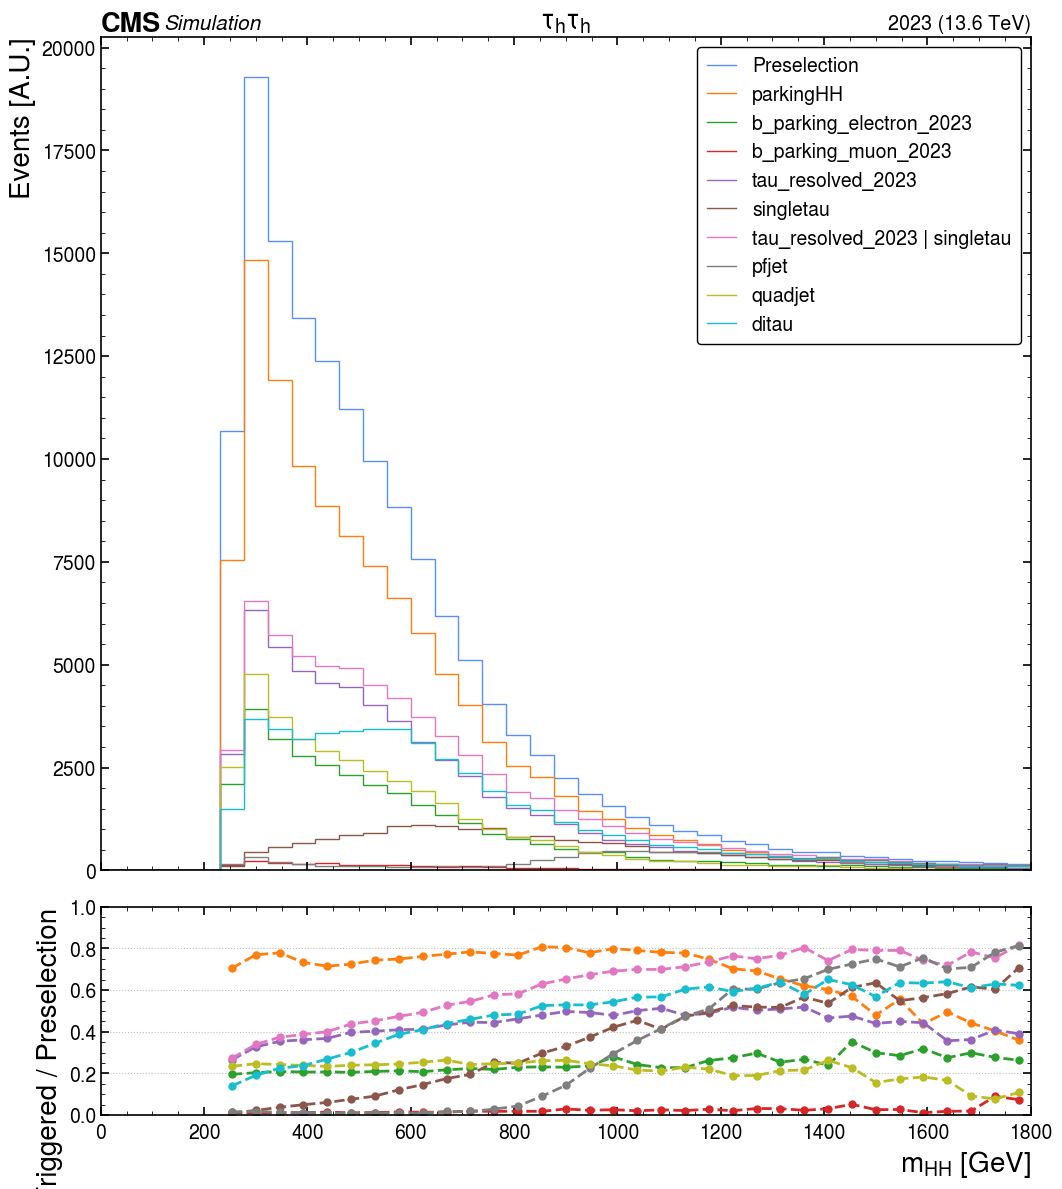

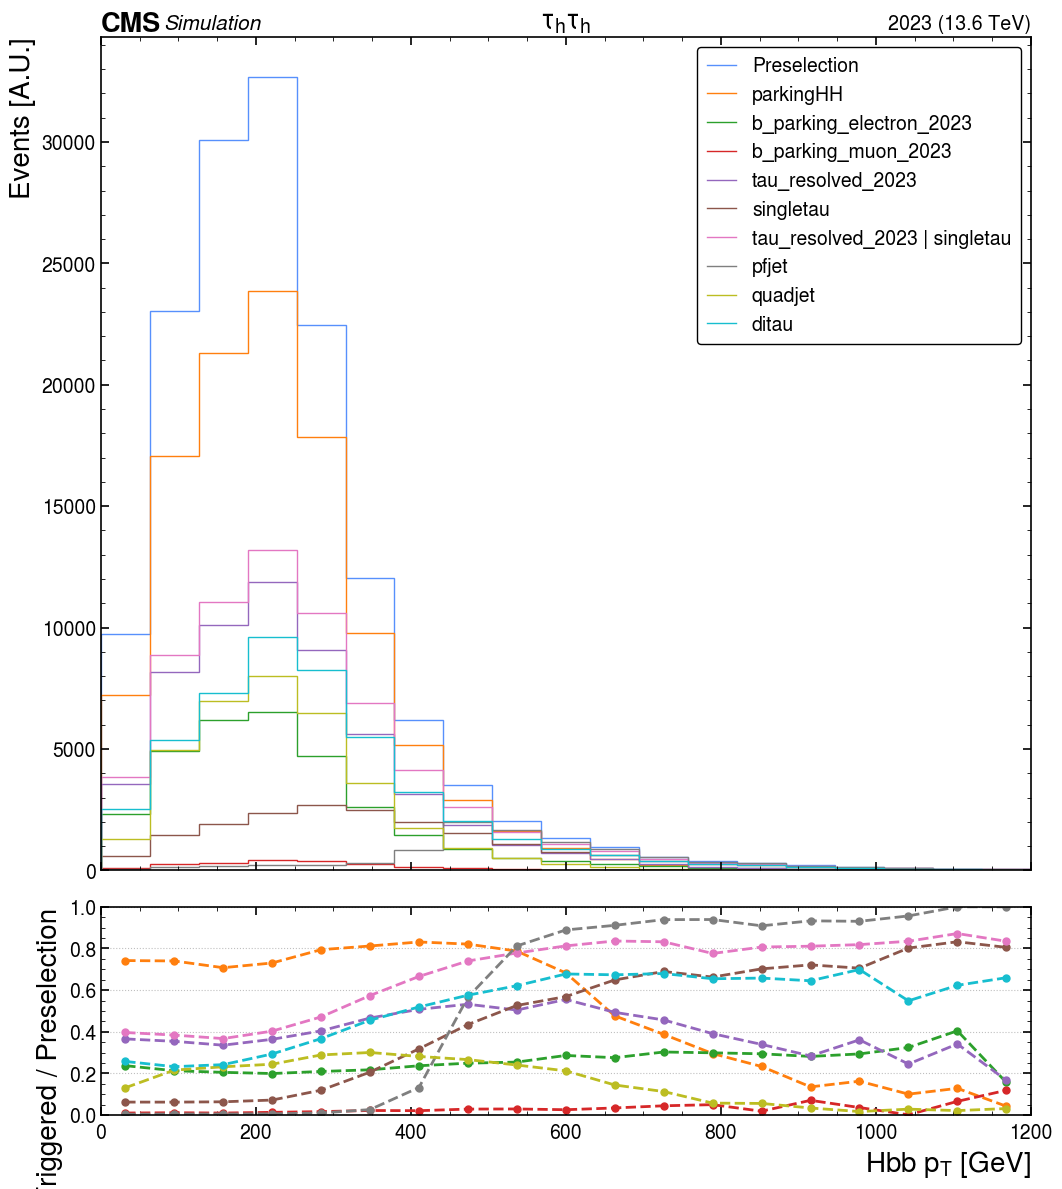

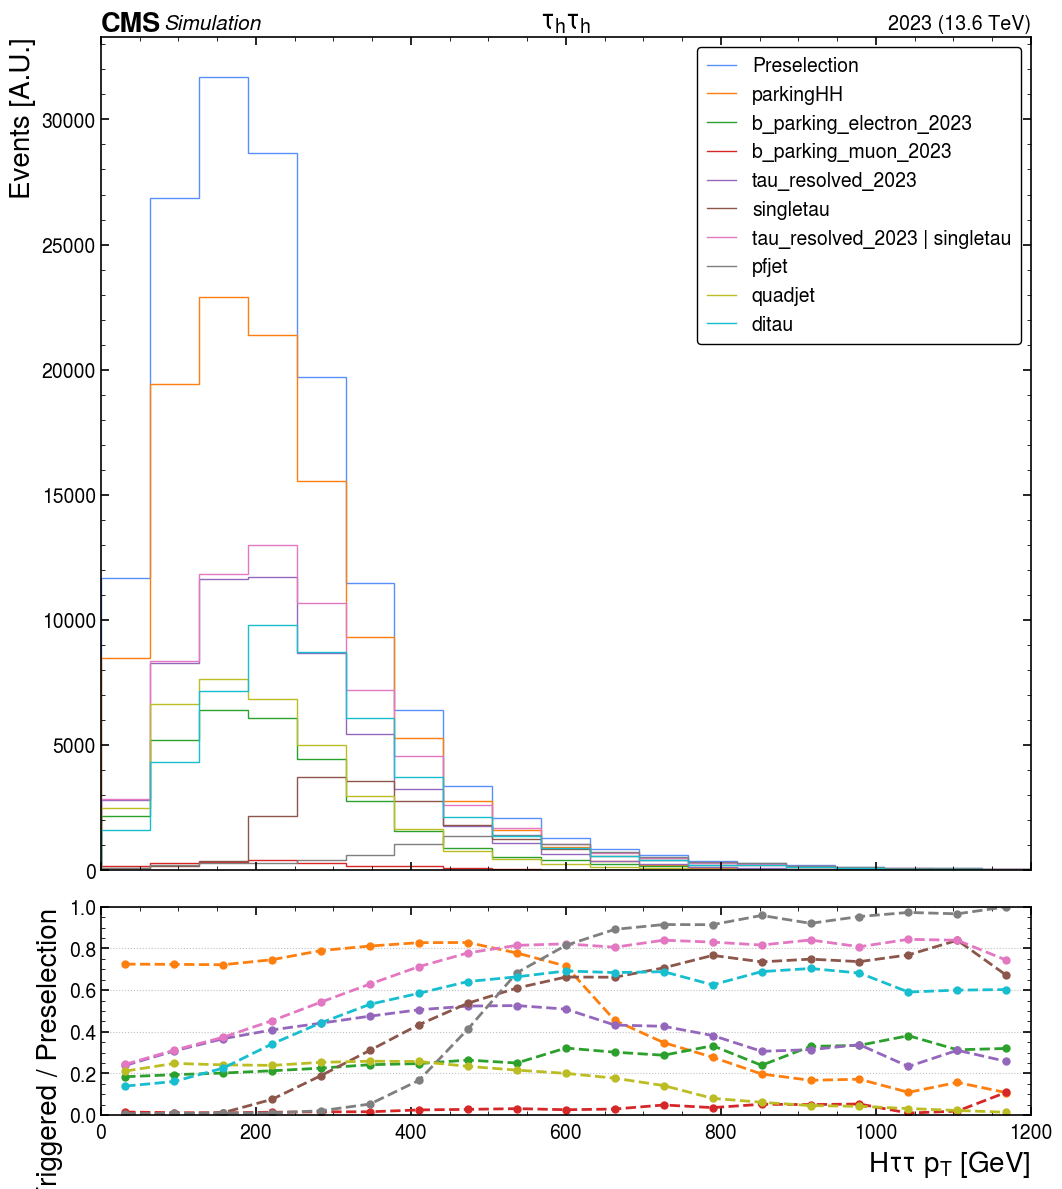

/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] 

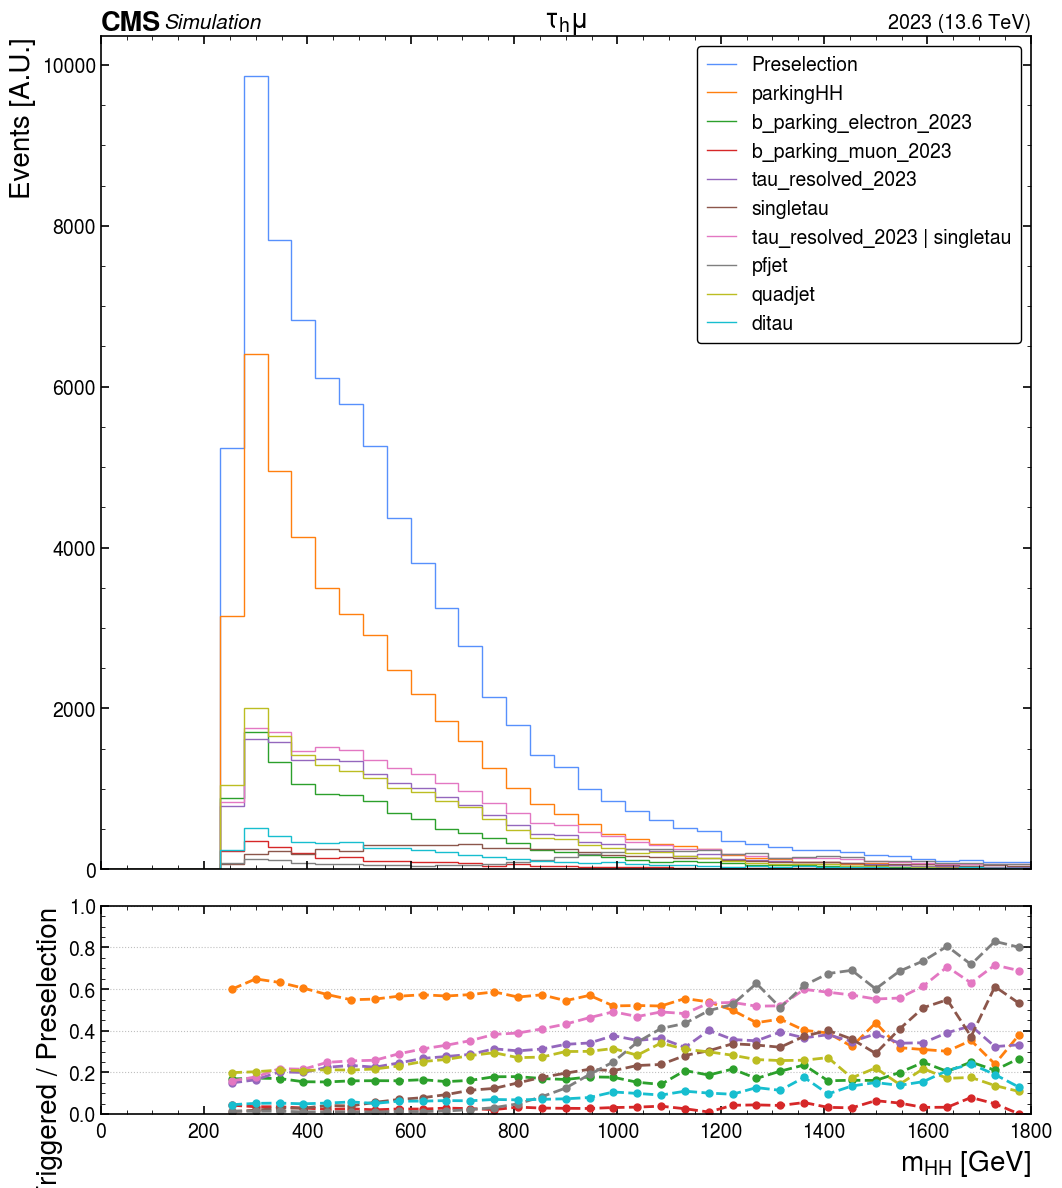

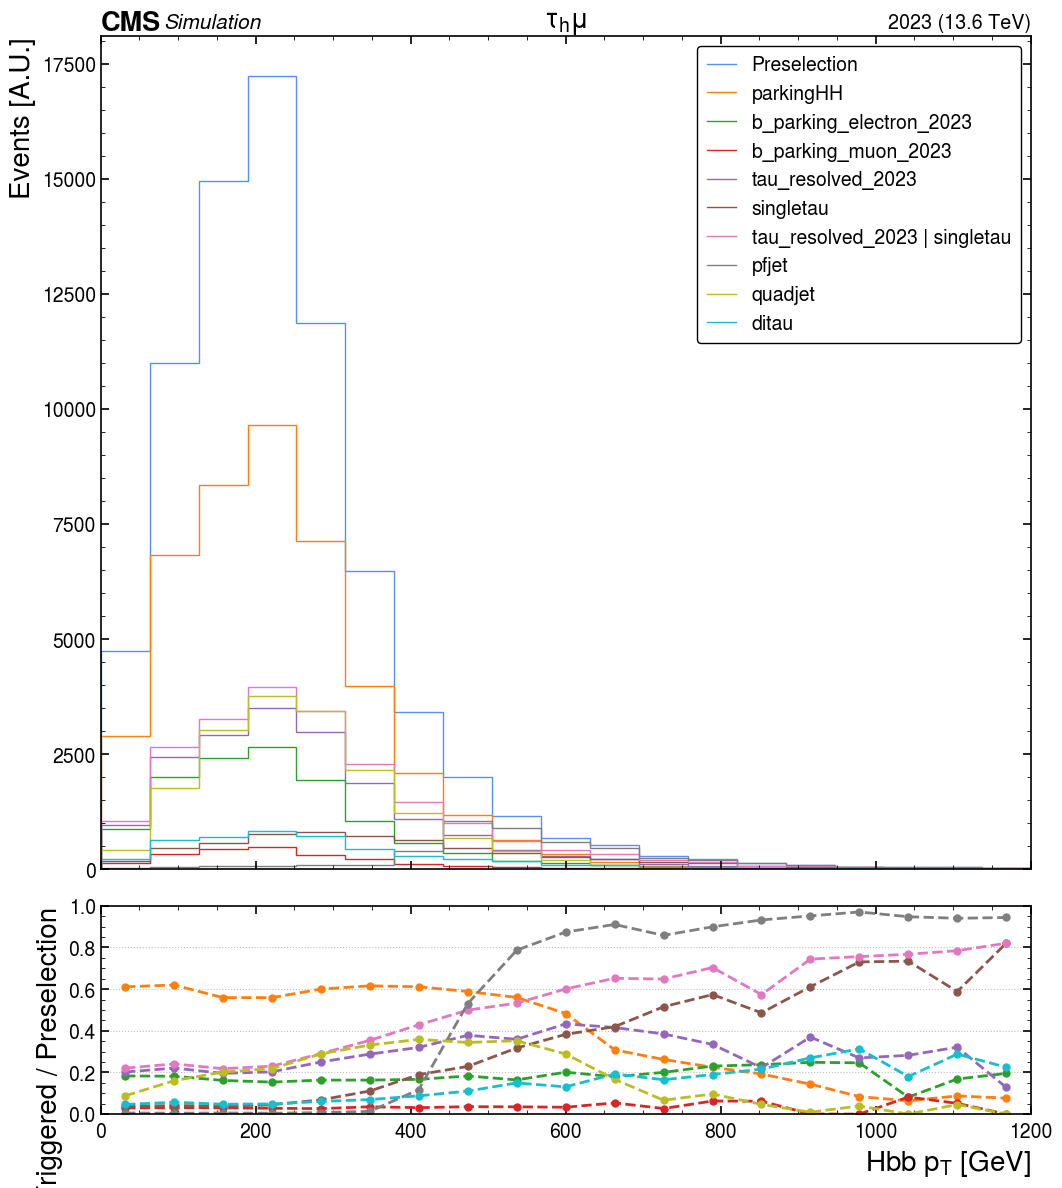

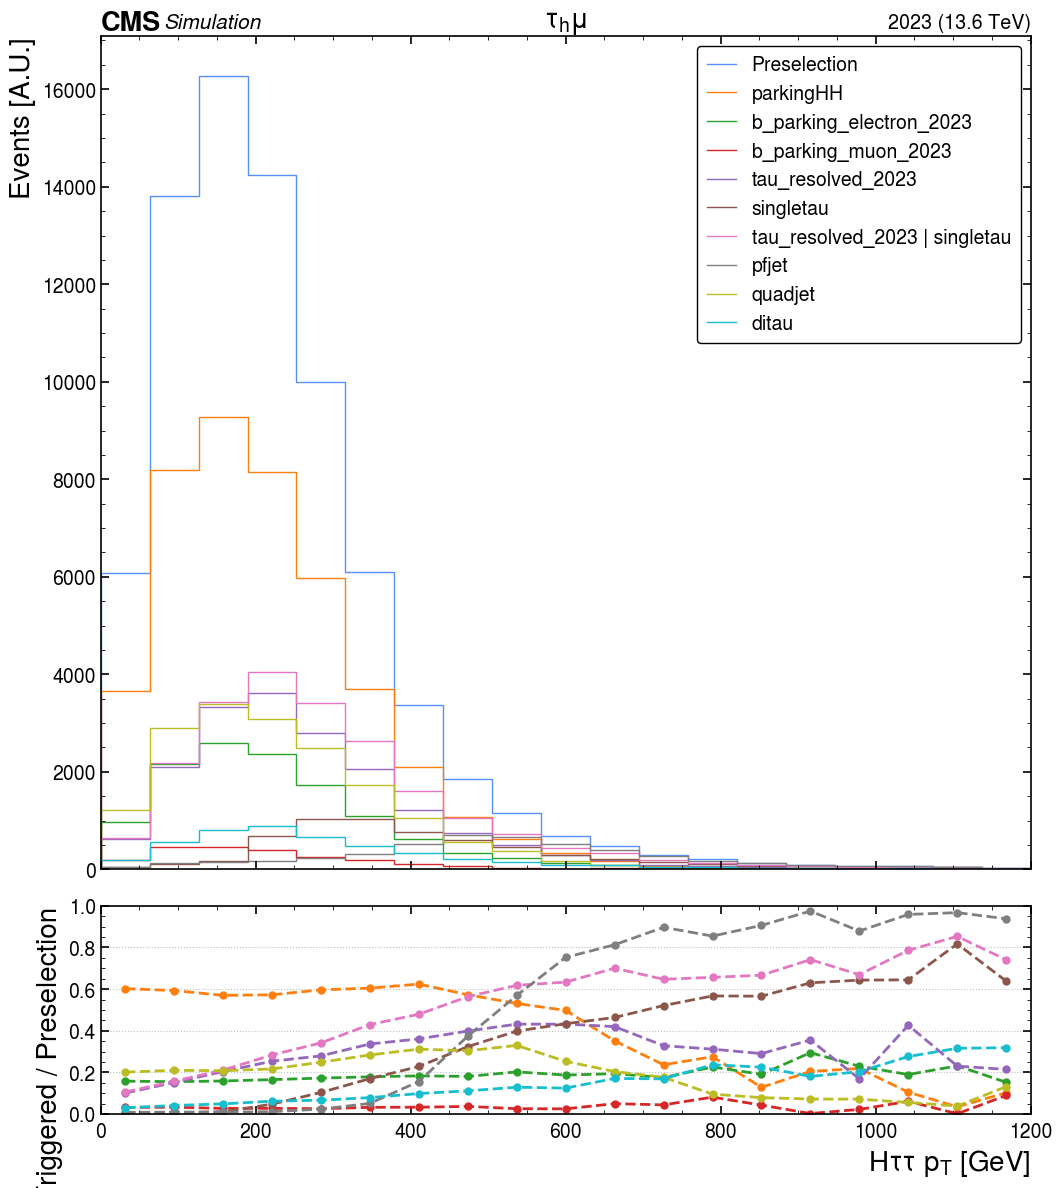

/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] = hists[key][0] / hists["Preselection"][0]
/tmp/ipykernel_1598452/424889852.py:73: RuntimeWarning: invalid value encountered in divide
  ratios[key] 

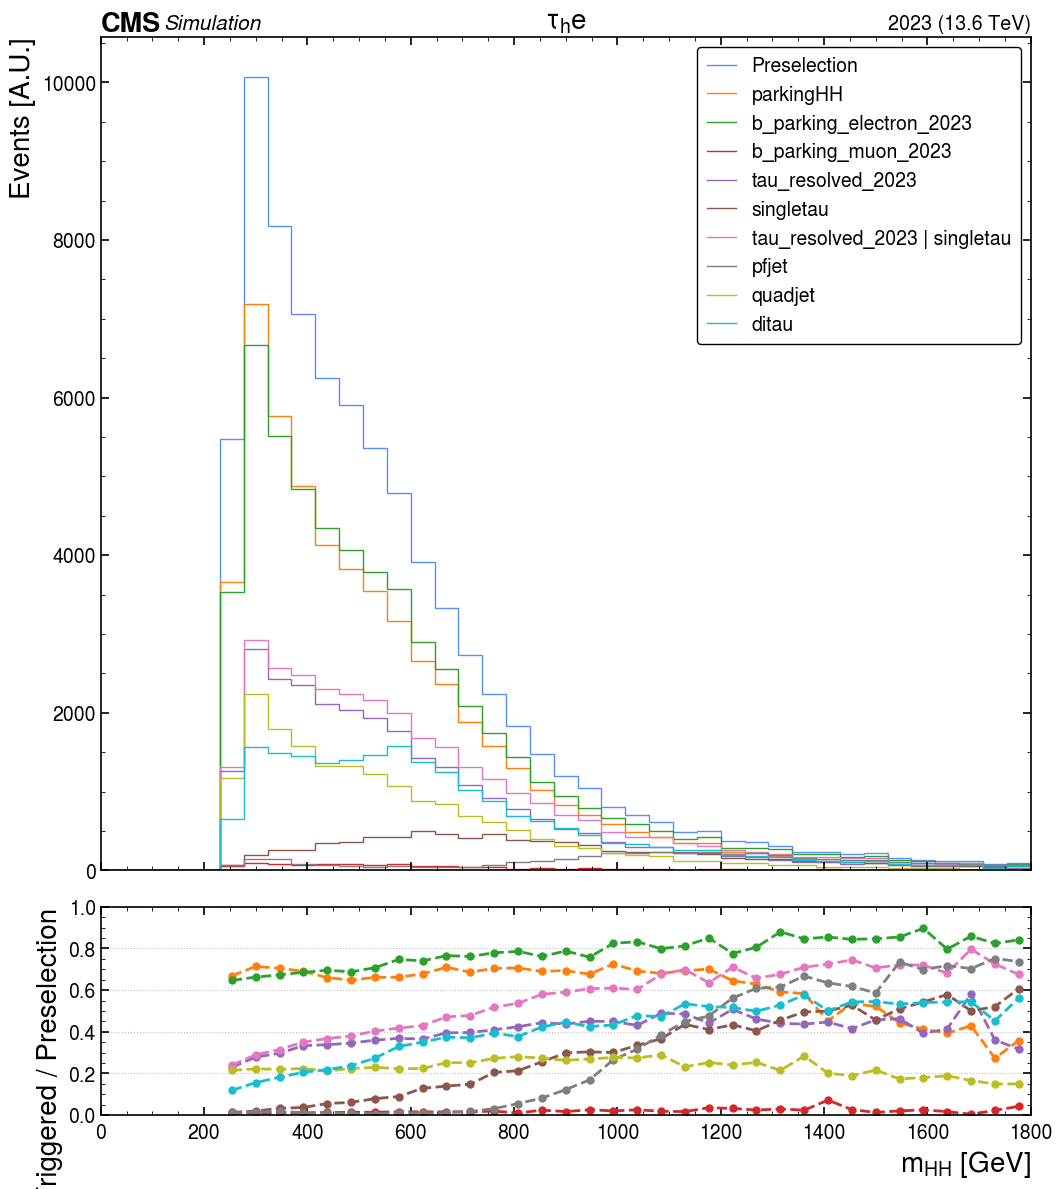

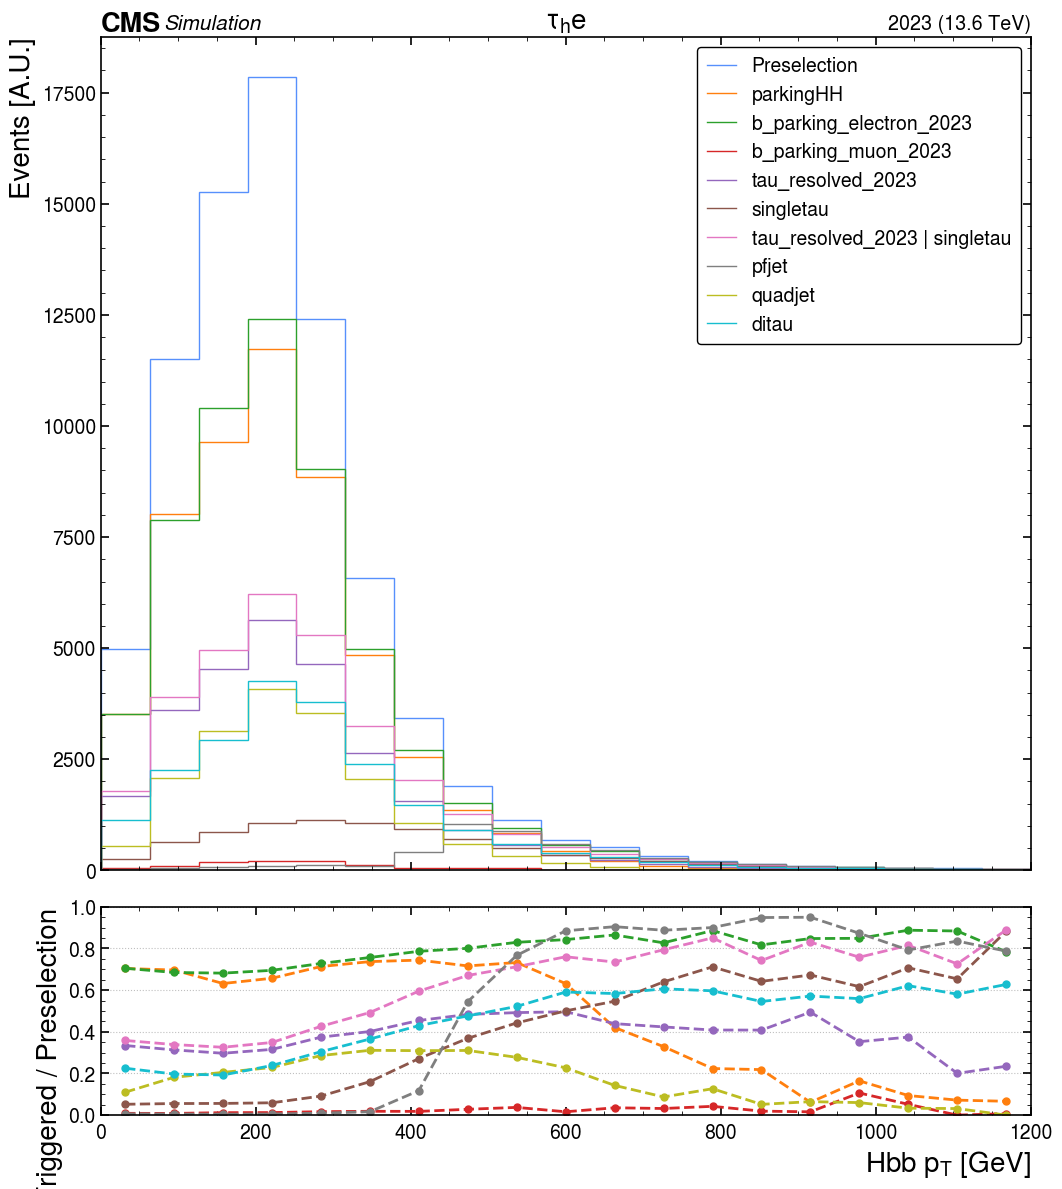

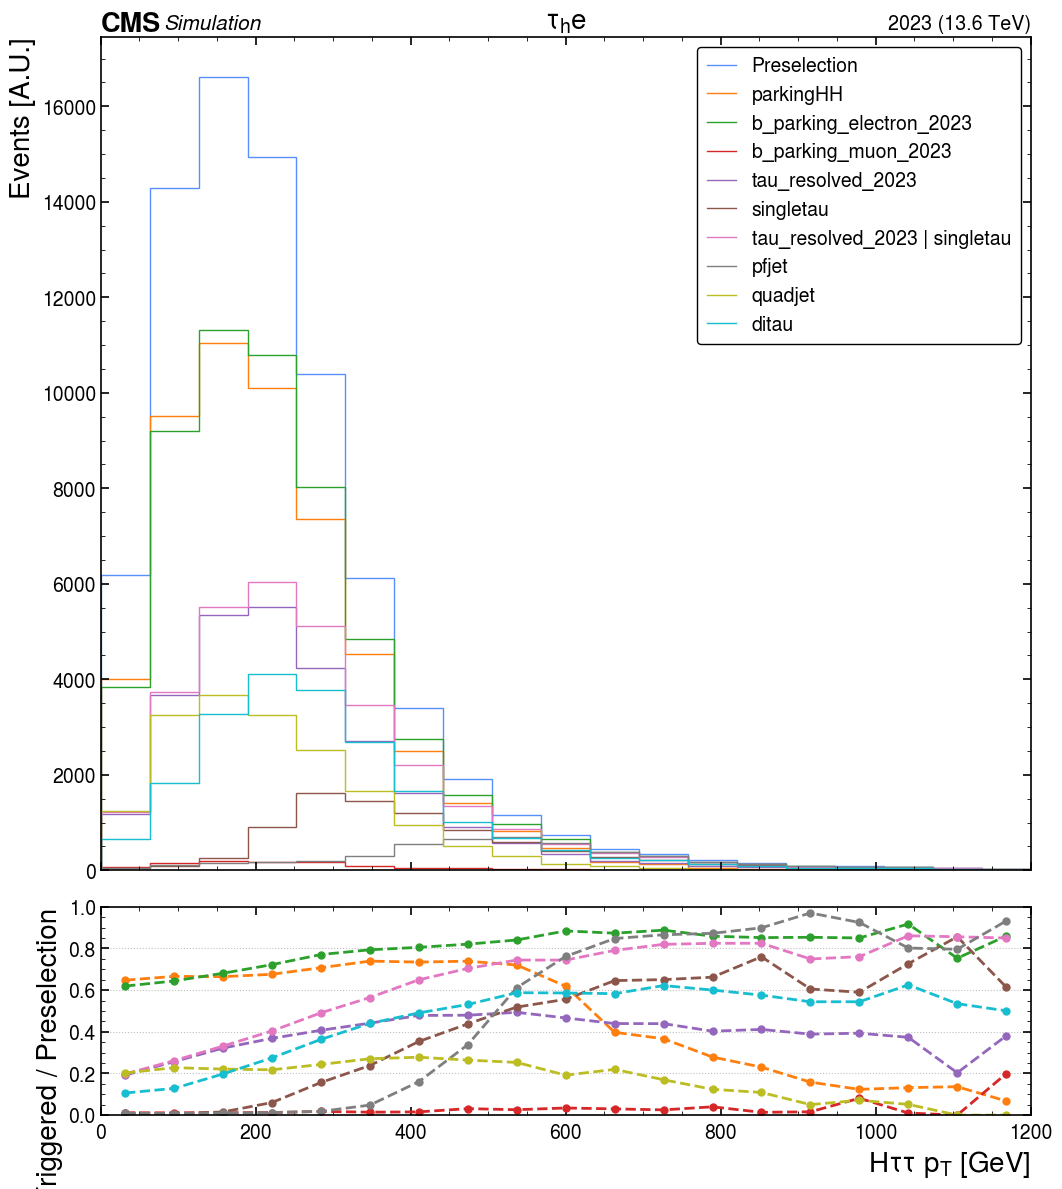

In [15]:
# plt.rcParams.update({"font.size": 14})
import mplhep as hep        # CMS/ATLAS/LHCb approved styles  <--:contentReference[oaicite:0]{index=0}

hep.style.use("CMS")

plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "legend.frameon": True,
    "legend.framealpha": 1.0,        
    "legend.facecolor": 'white',      
    "legend.edgecolor": 'black',      
    "legend.fancybox": True,         
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "lines.linewidth": 2,
    "axes.linewidth": 1.2,

    "figure.dpi": 100,          
    "savefig.dpi": 300,   

    "figure.figsize": (10, 7),   

})
# plot_vars = [
#     (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(250, 1500, 30)),
#     (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(250, 500, 20)),
#     (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
# ]


plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(0, 1800, 40)),
    (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(0, 1200, 20)),
    (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(0, 1200, 20)),
]

for cat, vals in triggers_dict.items():
    for kinvar, kinname, kinlabel, bins in plot_vars:
        (mask, label, triggers) = vals.values()

        fig, (ax, rax) = plt.subplots(
            2, 1, figsize=(12, 14), gridspec_kw=dict(height_ratios=[4, 1], hspace=0.07), sharex=True
        )

        hists = {"Preselection": np.histogram(kinvar[mask], bins=bins, weights=weights[mask])}
        ratios = {}

        hep.histplot(
            hists["Preselection"],
            yerr=False,
            label="Preselection",
            ax=ax,
        )

        colours = plt.cm.tab10.colors[1:]

        for key, c in zip(triggers.keys(), colours):
            # print(key)
            hists[key] = np.histogram(
                kinvar[mask & triggers[key]], bins=bins, weights=weights[mask & triggers[key]]
            )
            ratios[key] = hists[key][0] / hists["Preselection"][0]

            hep.histplot(
                hists[key],
                yerr=False,
                label=key,
                ax=ax,
                color=c,
            )

            hep.histplot(
                (ratios[key], bins),
                yerr=False,
                label=key,
                ax=rax,
                histtype="errorbar",
                color=c,
                # markersize=20,
                linestyle="--",
                # markeredgewidth=3,
                # fillstyle='none',
            )

        ax.set_ylabel("Events [A.U.]")
        ax.legend()
        ax.set_title(label)
        ax.set_xlim(bins[0], bins[-1])
        ax.set_ylim(0)

        # rax.legend()
        rax.grid(axis="y")
        rax.set_xlabel(kinlabel)
        rax.set_ylabel("Triggered / Preselection")

        ylims = [0.5, 1] if (cat.endswith("minus") and kinname != "mhh") else [0, 1]
        rax.set_ylim(ylims)

        hep.cms.label(ax=ax, data=False, year=2023, com="13.6")

        # plt.savefig(plot_dir / f"{kinname}_{cat}.pdf", bbox_inches="tight")
        plt.show()

In [ ]:
cats = [cat for cat in triggers_dict.keys() if not cat.endswith("minus")]
boostedsels = {
    "1 boosted jet (> 250)": df["ak8FatJetPt"][0] > 250,
    "2 boosted jets (> 250)": (df["ak8FatJetPt"][0] > 250) & (df["ak8FatJetPt"][1] > 250),
    "2 boosted jets (> 300)": (df["ak8FatJetPt"][0] > 300) & (df["ak8FatJetPt"][1] > 300),
}

for cat in cats:
    trig_table = pd.DataFrame(index=list(boostedsels.keys()))
    mask = triggers_dict[cat]["mask"]

    for tkey, tsel in triggers_dict[f"{cat}_minus"]["triggers"].items():
        effs = []
        for bkey, sel in boostedsels.items():
            eff = np.sum(mask & sel & tsel) / np.sum(mask & sel)
            effs.append(f"{eff * 100:.1f}")

        ttkey = tkey.replace("- ", "-") if tkey.startswith("-") else "All"
        trig_table[ttkey] = effs

    trig_table.to_csv(plot_dir / f"trig_effs_{cat}.csv")
    print(trig_table)

                         All -PNetBB -PNetTauTau -PFJet425 -Quad-jet  \
1 boosted jet (> 250)   80.9    74.3        79.8      80.7      74.3   
2 boosted jets (> 250)  94.4    90.9        93.0      94.2      92.3   
2 boosted jets (> 300)  97.2    94.9        96.4      96.9      96.2   

                       -SingleTau -Di-tau  
1 boosted jet (> 250)        73.8    72.4  
2 boosted jets (> 250)       87.6    92.8  
2 boosted jets (> 300)       93.3    96.5  
                         All -PNetBB -PNetTauTau -Muon -Mu-tau -SingleTau  \
1 boosted jet (> 250)   80.7    71.2        80.1  70.7    79.7       75.5   
2 boosted jets (> 250)  94.0    88.0        92.9  90.3    93.5       87.3   
2 boosted jets (> 300)  97.0    92.4        96.6  94.2    96.7       92.3   

                       -Di-tau -PFJet425  
1 boosted jet (> 250)     79.8      80.6  
2 boosted jets (> 250)    93.7      93.7  
2 boosted jets (> 300)    96.7      96.5  
                         All -PNetBB -PNetTauTau -EGam

In [ ]:
cats

['tauhh', 'tauhmu', 'tauhe']

In [ ]:
boostedsels

{'1 boosted jet (> 250)': 0         True
 1         True
 2         True
 3         True
 4         True
           ... 
 111432    True
 111433    True
 111434    True
 111435    True
 111436    True
 Name: 0, Length: 111437, dtype: bool,
 '2 boosted jets (> 250)': 0          True
 1          True
 2         False
 3         False
 4          True
           ...  
 111432     True
 111433    False
 111434    False
 111435    False
 111436    False
 Length: 111437, dtype: bool,
 '2 boosted jets (> 300)': 0          True
 1          True
 2         False
 3         False
 4          True
           ...  
 111432     True
 111433    False
 111434    False
 111435    False
 111436    False
 Length: 111437, dtype: bool}

In [ ]:
twoboosted = boostedsels["2 boosted jets (> 250)"]

In [ ]:
twoboosted

0          True
1          True
2         False
3         False
4          True
          ...  
111432     True
111433    False
111434    False
111435    False
111436    False
Length: 111437, dtype: bool

In [ ]:
mask = triggers_dict["tauhh"]["mask"]
print(
    np.sum(triggers_dict["tauhh"]["triggers"]["PNetBB | TauTau | SingleTau | Di-tau"][mask])
    / np.sum(mask)
)
print(
    np.sum(
        ((triggers_dict["tauhh"]["triggers"]["PNetBB | TauTau | SingleTau | Di-tau"]) * twoboosted)[
            mask
        ]
    )
    / np.sum((mask * twoboosted))
)

0.6781401220281927
0.920332936979786


In [ ]:
mask = triggers_dict["tauhmu"]["mask"]
print(
    np.sum(triggers_dict["tauhmu"]["triggers"]["PNetBB | TauTau | Muon | Mu-tau | SingleTau | Di-tau | PFJet425"][mask])
    / np.sum(mask)
)
print(
    np.sum(
        (
            (triggers_dict["tauhmu"]["triggers"]["PNetBB | TauTau | Muon | Mu-tau | SingleTau | Di-tau | PFJet425"])
            * twoboosted
        )[mask]
    )
    / np.sum((mask * twoboosted))
)

0.762652420374373
0.9404761904761905


In [ ]:
mask = triggers_dict["tauhe"]["mask"]
print(
    np.sum(triggers_dict["tauhe"]["triggers"]["PNetBB"][mask])
    / np.sum(mask)
)
print(
    np.sum(
        ((triggers_dict["tauhe"]["triggers"]["PNetBB"]) * twoboosted)[
            mask
        ]
    )
    / np.sum((mask * twoboosted))
)

print()

mask = triggers_dict["tauhe"]["mask"]
print(
    np.sum(triggers_dict["tauhe"]["triggers"]["PNetBB | TauTau | EGamma | e-tau | SingleTau | Di-tau | PFJet425"][mask])
    / np.sum(mask)
)
print(
    np.sum(
        ((triggers_dict["tauhe"]["triggers"]["PNetBB | TauTau | EGamma | e-tau | SingleTau | Di-tau | PFJet425"]) * twoboosted)[
            mask
        ]
    )
    / np.sum((mask * twoboosted))
)

0.345987292079809
0.6344212256398215

0.7442227528430936
0.9309697111998122


4b triggers

In [ ]:
bbbb_triggered = (
    df4b["HLT_AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35"][0]
    | df4b["HLT_AK8PFJet425_SoftDropMass40"][0]
)
higgs = utils.make_vector(df4b, name="GenHiggs")
mhh = (higgs[:, 0] + higgs[:, 1]).mass
weights = df4b["weight"][0]

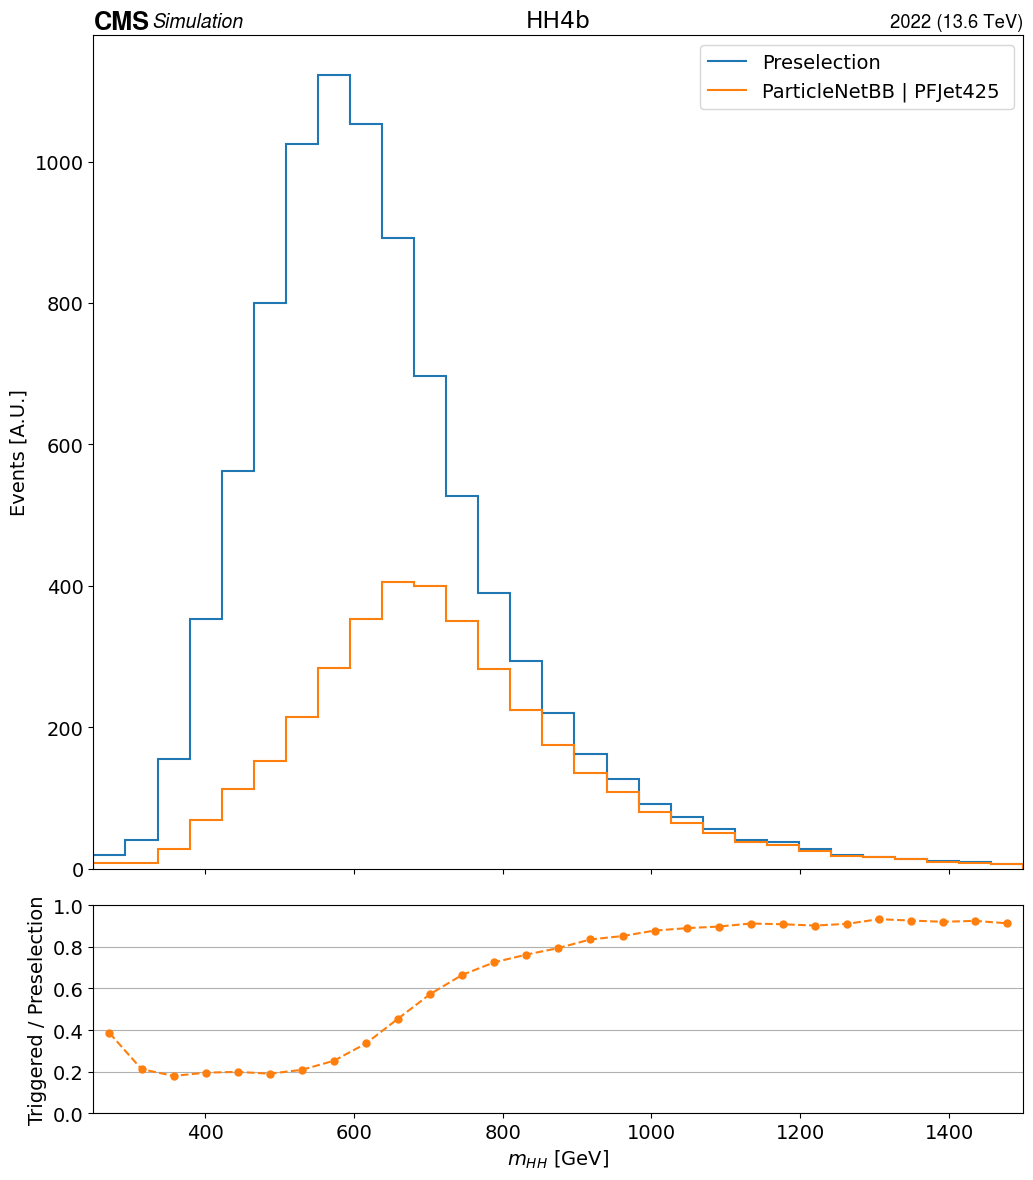

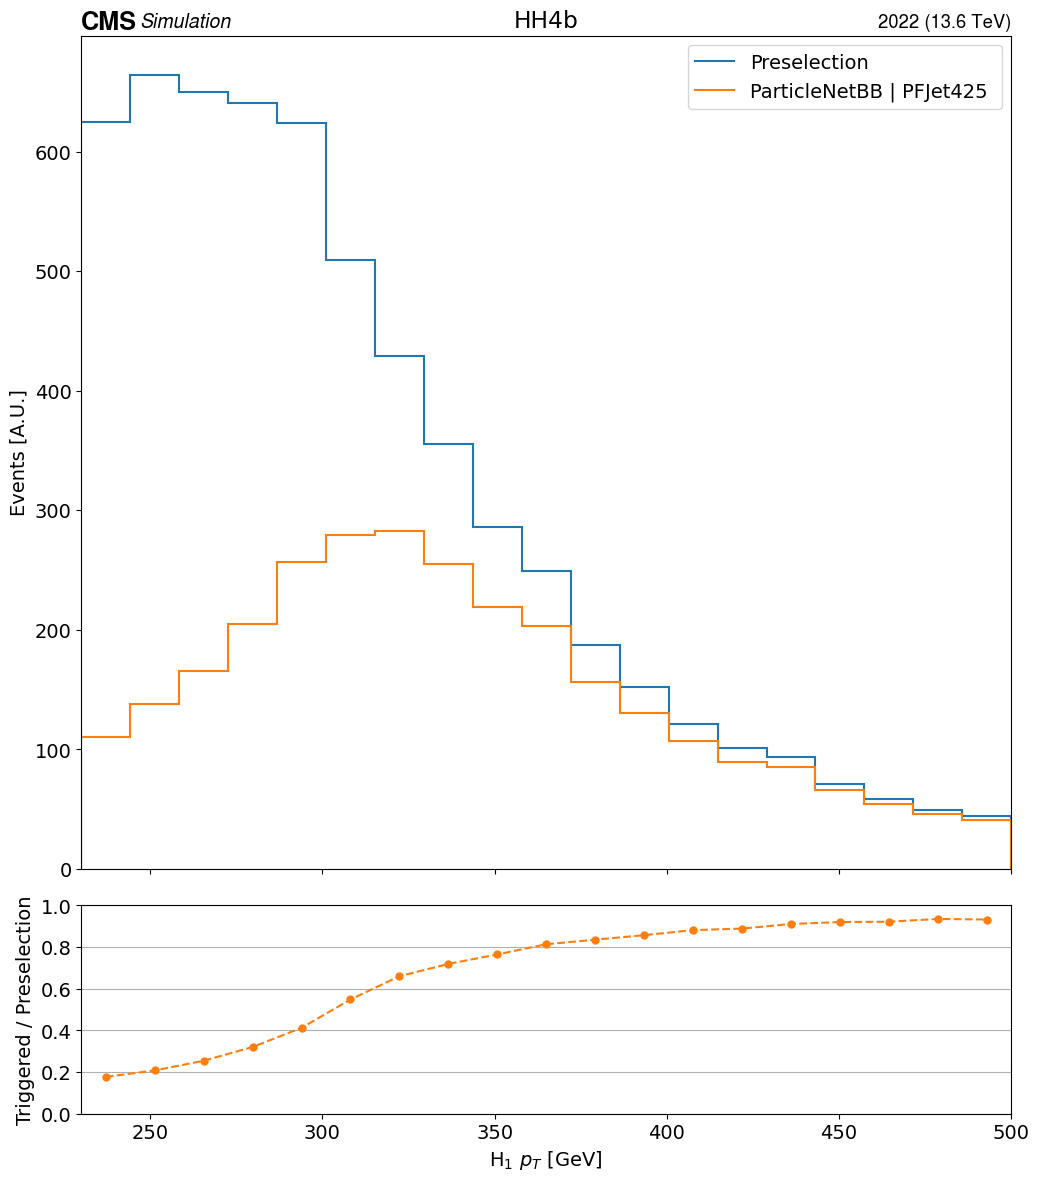

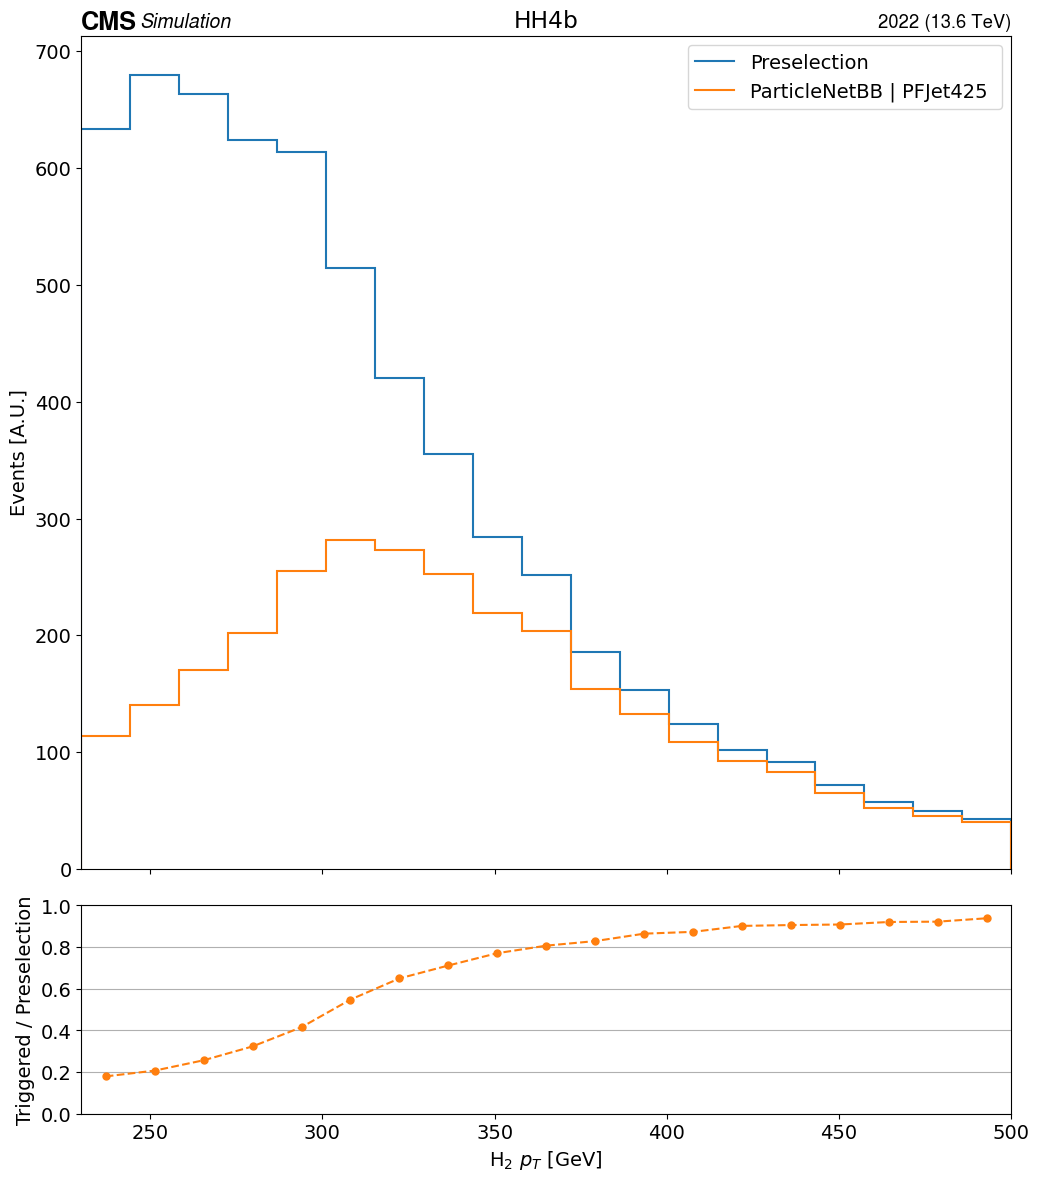

In [ ]:
plt.rcParams.update({"font.size": 14})

plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(250, 1500, 30)),
    (higgs[:, 0].pt, "hbbpt1", r"H$_1$ $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
    (higgs[:, 1].pt, "hbbpt2", r"H$_2$ $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
]

cat = "bbbb"
(mask, label, triggers) = (
    np.ones(len(df4b)).astype(bool),
    "HH4b",
    {"ParticleNetBB | PFJet425 ": bbbb_triggered},
)


for kinvar, kinname, kinlabel, bins in plot_vars:
    fig, (ax, rax) = plt.subplots(
        2, 1, figsize=(12, 14), gridspec_kw=dict(height_ratios=[4, 1], hspace=0.07), sharex=True
    )

    hists = {"Preselection": np.histogram(kinvar[mask], bins=bins, weights=weights[mask])}
    ratios = {}

    hep.histplot(
        hists["Preselection"],
        yerr=False,
        label="Preselection",
        ax=ax,
    )

    colours = plt.cm.tab10.colors[1:]

    for key, c in zip(triggers.keys(), colours):
        # print(key)
        hists[key] = np.histogram(
            kinvar[mask & triggers[key]], bins=bins, weights=weights[mask & triggers[key]]
        )
        ratios[key] = hists[key][0] / hists["Preselection"][0]

        hep.histplot(
            hists[key],
            yerr=False,
            label=key,
            ax=ax,
            color=c,
        )

        hep.histplot(
            (ratios[key], bins),
            yerr=False,
            label=key,
            ax=rax,
            histtype="errorbar",
            color=c,
            # markersize=20,
            linestyle="--",
            # markeredgewidth=3,
            # fillstyle='none',
        )

    ax.set_ylabel("Events [A.U.]")
    ax.legend()
    ax.set_title(label)
    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylim(0)

    # rax.legend()
    rax.grid(axis="y")
    rax.set_xlabel(kinlabel)
    rax.set_ylabel("Triggered / Preselection")

    ylims = [0.5, 1] if (cat.endswith("minus") and kinname != "mhh") else [0, 1]
    rax.set_ylim(ylims)

    hep.cms.label(ax=ax, data=False, year=2023, com="13.6")

    plt.savefig(plot_dir / f"{kinname}_{cat}.pdf", bbox_inches="tight")
    plt.show()

ParticleNetBB | PFJet425 


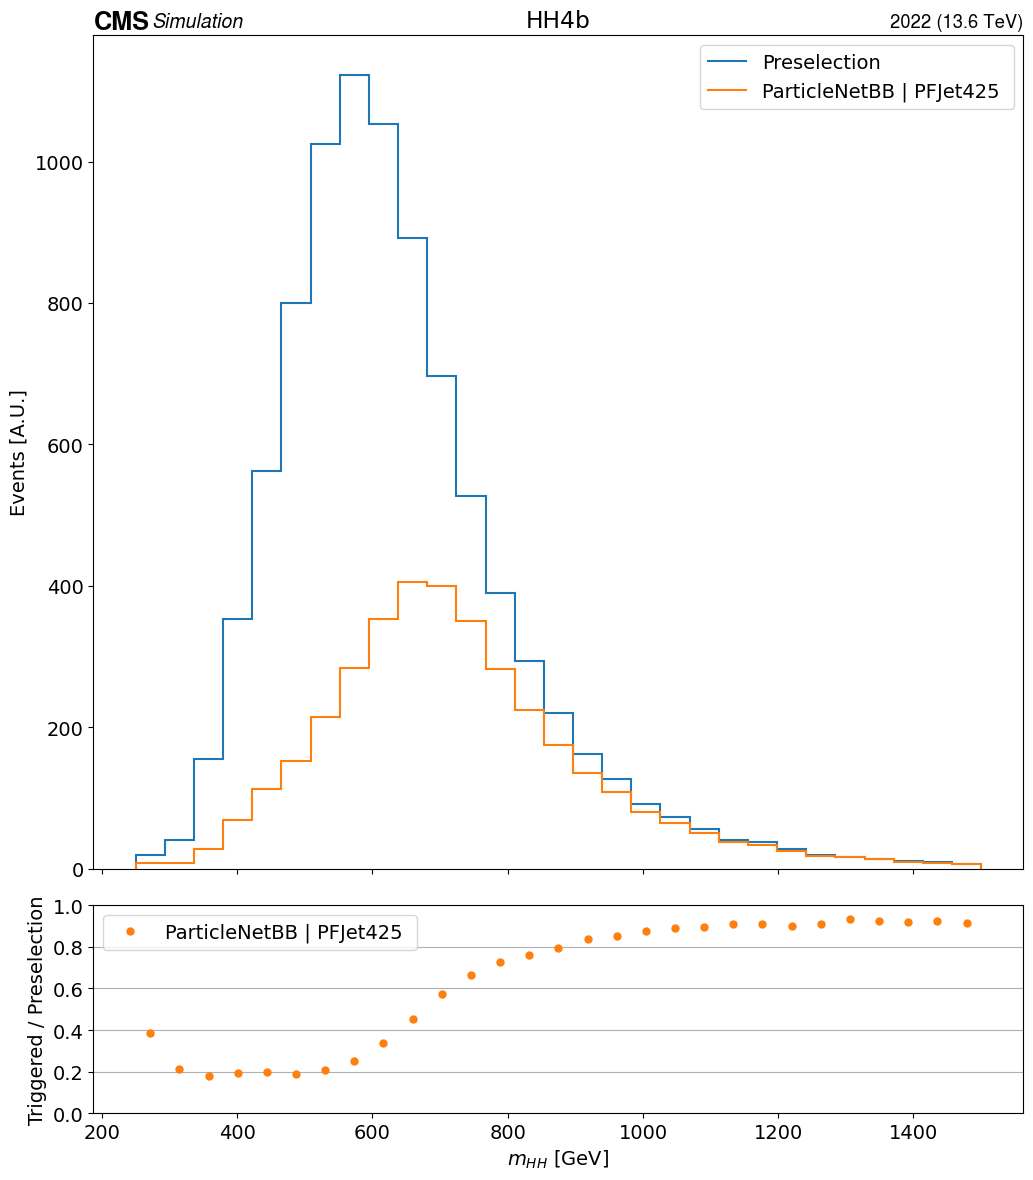

In [ ]:
plt.rcParams.update({"font.size": 14})


fig, (ax, rax) = plt.subplots(
    2, 1, figsize=(12, 14), gridspec_kw=dict(height_ratios=[4, 1], hspace=0.07), sharex=True
)

bins = np.linspace(250, 1500, 30)
hists = {"Preselection": np.histogram(mhh[mask], bins=bins, weights=weights[mask])}
ratios = {}

hep.histplot(
    hists["Preselection"],
    yerr=False,
    label="Preselection",
    ax=ax,
)

colours = plt.cm.tab10.colors[1:]

for key, c in zip(triggers.keys(), colours):
    print(key)
    hists[key] = np.histogram(
        mhh[mask & triggers[key]], bins=bins, weights=weights[mask & triggers[key]]
    )
    ratios[key] = hists[key][0] / hists["Preselection"][0]

    hep.histplot(
        hists[key],
        yerr=False,
        label=key,
        ax=ax,
        color=c,
    )

    hep.histplot(
        (ratios[key], bins),
        yerr=False,
        label=key,
        ax=rax,
        histtype="errorbar",
        color=c,
        capsize=4,
    )

ax.set_ylabel("Events [A.U.]")
ax.legend()
ax.set_title(label)

rax.legend()
rax.grid(axis="y")
rax.set_xlabel(r"$m_{HH}$ [GeV]")
rax.set_ylabel("Triggered / Preselection")
rax.set_ylim(0, 1)

hep.cms.label(ax=ax, data=False, year=2023, com="13.6")

plt.savefig(plot_dir / f"mhh_{cat}.pdf", bbox_inches="tight")
plt.show()

In [ ]:
twoboosted = df4b["ak8FatJetPt"][1] > 300
print(np.mean(bbbb_triggered))
print(np.sum(bbbb_triggered * twoboosted) / np.sum((twoboosted)))

0.4284078800207832
0.893295500608026


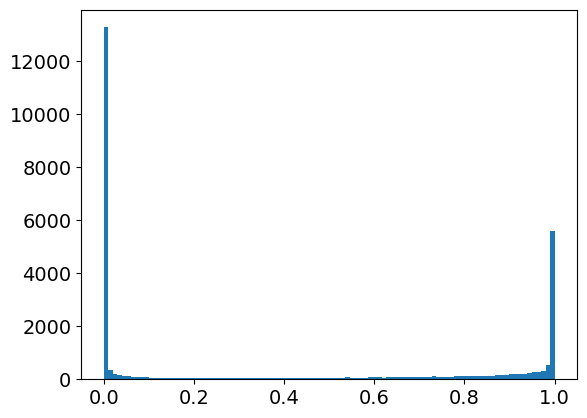

In [ ]:
ptaus = df["ak8FatJetParTXtauhtauh"] + df["ak8FatJetParTXtauhtaue"] + df["ak8FatJetParTXtauhtaum"]
plt.hist(ptaus[1], np.linspace(0, 1, 100))
plt.show()
# df["ak8FatJetParTXtauhtauh"]

In [ ]:
for _ in (df.keys()):
    print(_,end = "\n")

('GenHiggsEta', 0)
('GenHiggsEta', 1)
('GenHiggsPhi', 0)
('GenHiggsPhi', 1)
('GenHiggsMass', 0)
('GenHiggsMass', 1)
('GenHiggsPt', 0)
('GenHiggsPt', 1)
('GenHiggsChildren', 0)
('GenHiggsChildren', 1)
('GenbbEta', 0)
('GenbbEta', 1)
('GenbbPhi', 0)
('GenbbPhi', 1)
('GenbbMass', 0)
('GenbbMass', 1)
('GenbbPt', 0)
('GenbbPt', 1)
('GenTauEta', 0)
('GenTauEta', 1)
('GenTauPhi', 0)
('GenTauPhi', 1)
('GenTauMass', 0)
('GenTauMass', 1)
('GenTauPt', 0)
('GenTauPt', 1)
('GenTauhh', 0)
('GenTauhmu', 0)
('GenTauhe', 0)
('run', 0)
('event', 0)
('luminosityBlock', 0)
('MET_pt', 0)
('ht', 0)
('nJets', 0)
('nFatJets', 0)
('nPU', 0)
('nPV', 0)
('HLT_AK8PFJet425_SoftDropMass40', 0)
('HLT_AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35', 0)
('HLT_AK8PFJet230_SoftDropMass40_PFAK8ParticleNetTauTau0p30', 0)
('HLT_QuadPFJet70_50_40_35_PFBTagParticleNet_2BTagSum0p65', 0)
('HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1', 0)
('HLT_DoubleMediumDeepTauPFTauHPS35_L2NN_eta2p1', 0)
('HLT_DoubleMediumDeepTauPFTauHPS30_L2

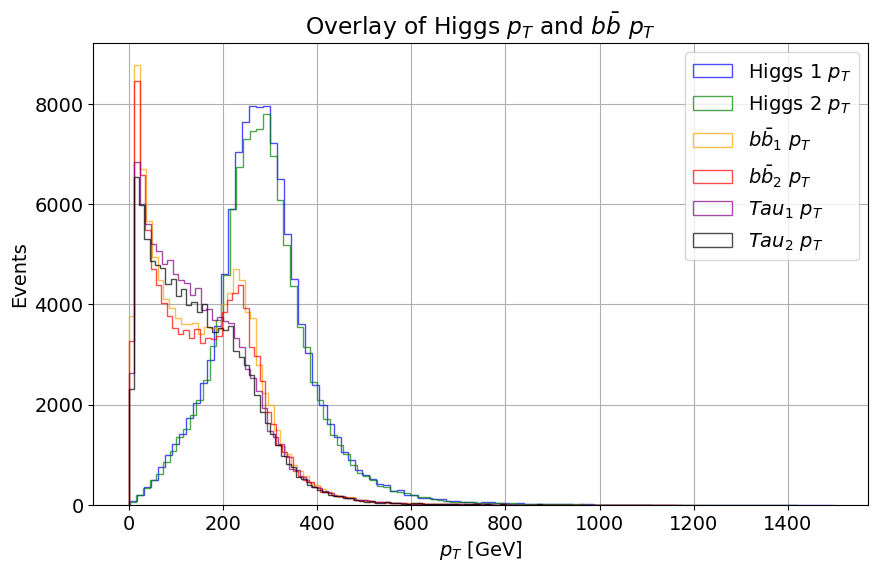

In [ ]:
higgs1_pt = df[("GenHiggsPt", 0)]
higgs2_pt = df[("GenHiggsPt", 1)]
bb1_pt = df[("GenbbPt", 0)]
bb2_pt = df[("GenbbPt", 1)]

Tau1_pt = df[("GenTauPt", 0)]
Tau2_pt = df[("GenTauPt", 1)]

plt.figure(figsize=(10, 6))
plt.hist(higgs1_pt, bins=100, alpha=0.7, label="Higgs 1 $p_T$", histtype="step", color="blue")
plt.hist(higgs2_pt, bins=100, alpha=0.7, label="Higgs 2 $p_T$", histtype="step", color="green")

plt.hist(bb1_pt, bins=100, alpha=0.7, label="$b\\bar{b}_1$ $p_T$", histtype="step", color="orange")
plt.hist(bb2_pt, bins=100, alpha=0.7, label="$b\\bar{b}_2$ $p_T$", histtype="step", color="red")

plt.hist(Tau1_pt, bins=100, alpha=0.7, label="$Tau_1$ $p_T$", histtype="step", color="purple")
plt.hist(Tau2_pt, bins=100, alpha=0.7, label="$Tau_2$ $p_T$", histtype="step", color="black")

plt.xlabel("$p_T$ [GeV]")
plt.ylabel("Events")
plt.title("Overlay of Higgs $p_T$ and $b\\bar{b}$ $p_T$")
plt.legend()
plt.grid(True)
plt.savefig("overlay_higgs_bb_pt.png")
plt.show()

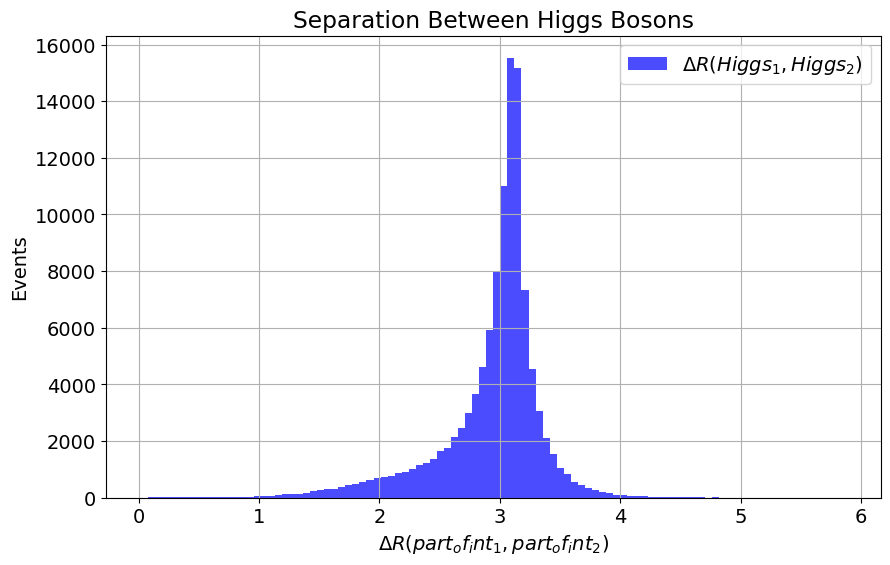

In [ ]:
# Boosted Topology: When the decay products (eg. b\bar{b}) are close together in Delta R
# Resolved Topology: When the  decay productsare well seperated

part_of_int = 'Higgs'

delta_eta_hh = df[(f"Gen{part_of_int}Eta", 0)] - df[(f"Gen{part_of_int}Eta", 1)]
delta_phi_hh = np.abs(df[(f"Gen{part_of_int}Phi", 0)] - df[(f"Gen{part_of_int}Phi", 1)])
delta_phi_hh = np.where(delta_phi_hh > np.pi, 2 * np.pi - delta_phi_hh, delta_phi_hh)  # Wrap around pi
delta_r_hh = np.sqrt(delta_eta_hh**2 + delta_phi_hh**2) # \Delta R (Spatial Correlation)

plt.figure(figsize=(10, 6))
plt.hist(delta_r_hh, bins=100, alpha=0.7, label=rf"$\Delta R({part_of_int}_1, {part_of_int}_2)$", color="blue")
plt.xlabel(rf"$\Delta R({{part_of_int}}_1, {{part_of_int}}_2)$")
plt.ylabel("Events")
plt.title(f"Separation Between {part_of_int} Bosons")
plt.legend()
plt.grid(True)
plt.savefig("delta_r_higgs.png")
plt.show()

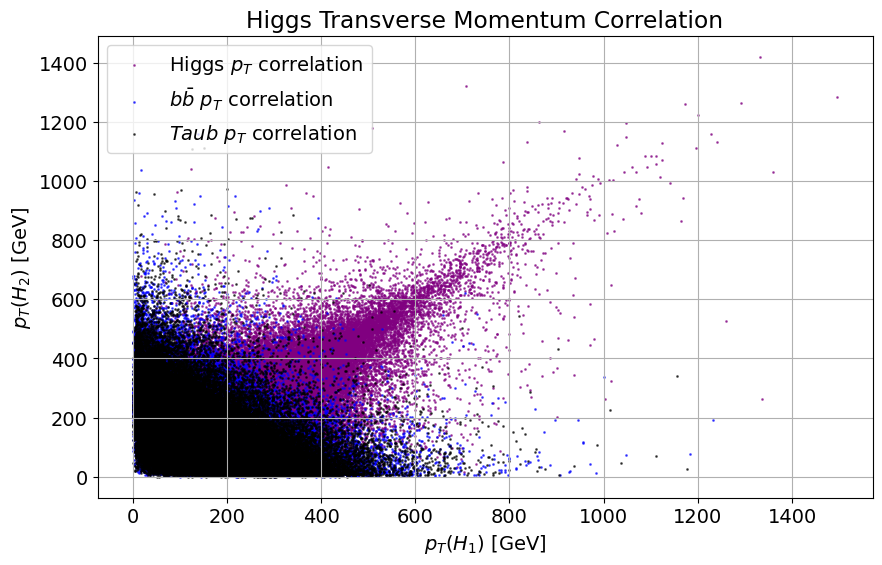

In [ ]:
# Scatterplot: Higgs1 pT vs. Higgs2 pT
plt.figure(figsize=(10, 6))

plt.scatter(higgs1_pt, higgs2_pt, alpha=0.6, s = 1, label="Higgs $p_T$ correlation", color="purple")
plt.scatter(bb1_pt, bb2_pt, alpha=0.6, s = 1, label="$b\\bar{b}$ $p_T$ correlation", color="blue")
plt.scatter(Tau1_pt, Tau2_pt, alpha=0.6, s = 1, label="$Tau{b}$ $p_T$ correlation", color="black")

plt.xlabel("$p_T(H_1)$ [GeV]")
plt.ylabel("$p_T(H_2)$ [GeV]")
plt.title("Higgs Transverse Momentum Correlation")
plt.legend()
plt.grid(True)
plt.savefig("higgs_pt_correlation.png")
plt.show()

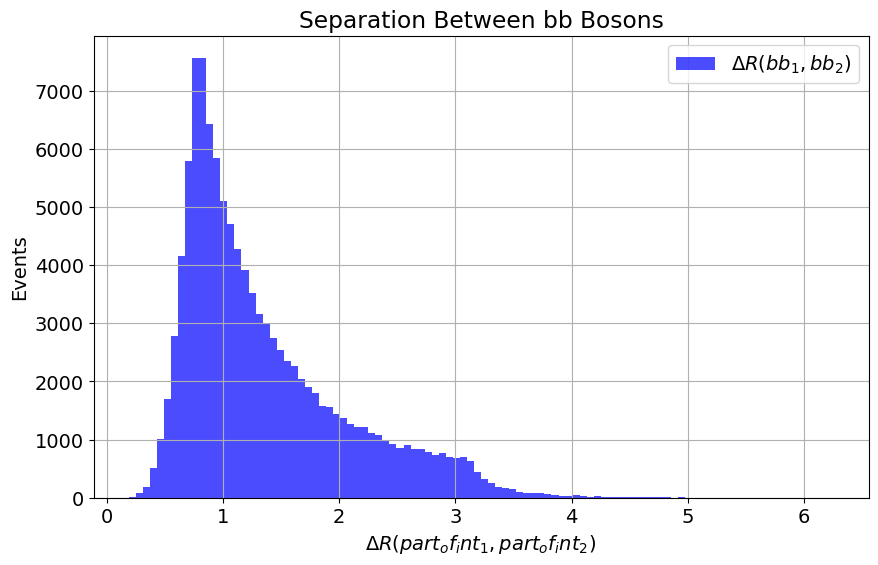

In [ ]:
# Boosted Topology: When the decay products (eg. b\bar{b}) are close together in Delta R
# Resolved Topology: When the  decay productsare well seperated

part_of_int = 'bb' # Ths is bb but think it is supposed to be just b
# HH-> bb tautau
# It should be someting like this right?

delta_eta_hh = df[(f"Gen{part_of_int}Eta", 0)] - df[(f"Gen{part_of_int}Eta", 1)]
delta_phi_hh = np.abs(df[(f"Gen{part_of_int}Phi", 0)] - df[(f"Gen{part_of_int}Phi", 1)])
delta_phi_hh = np.where(delta_phi_hh > np.pi, 2 * np.pi - delta_phi_hh, delta_phi_hh)  # Wrap around pi
delta_r_hh = np.sqrt(delta_eta_hh**2 + delta_phi_hh**2) # \Delta R (Spatial Correlation)

plt.figure(figsize=(10, 6))
plt.hist(delta_r_hh, bins=100, alpha=0.7, label=rf"$\Delta R({part_of_int}_1, {part_of_int}_2)$", color="blue")
plt.xlabel(rf"$\Delta R({{part_of_int}}_1, {{part_of_int}}_2)$")
plt.ylabel("Events")
plt.title(f"Separation Between {part_of_int} Bosons")
plt.legend()
plt.grid(True)
plt.savefig("delta_r_higgs.png")
plt.show()


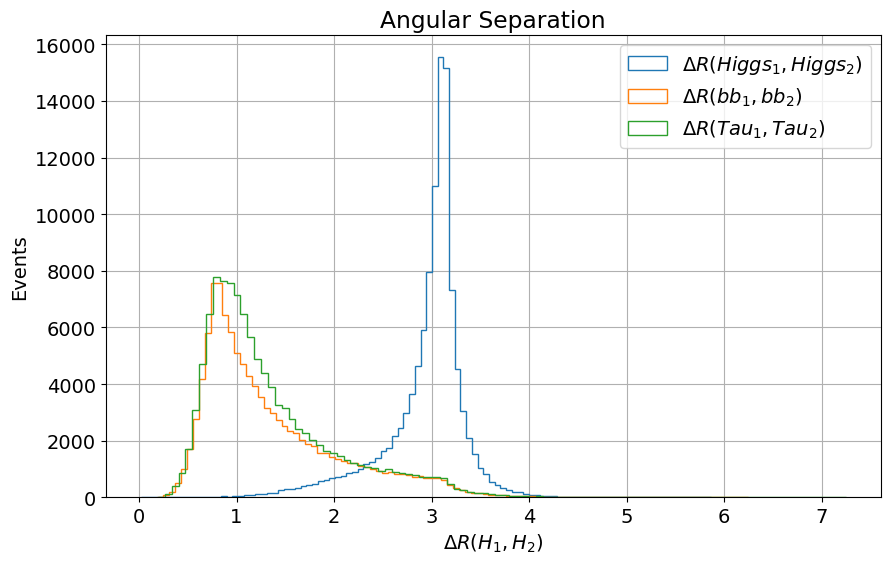

In [ ]:
part_of_int_list = ['Higgs', 'bb', 'Tau']

plt.figure(figsize=(10, 6))
for part_of_int in part_of_int_list:
    delta_eta_hh = df[(f"Gen{part_of_int}Eta", 0)] - df[(f"Gen{part_of_int}Eta", 1)]
    delta_phi_hh = np.abs(df[(f"Gen{part_of_int}Phi", 0)] - df[(f"Gen{part_of_int}Phi", 1)])
    delta_phi_hh = np.where(delta_phi_hh > np.pi, 2 * np.pi - delta_phi_hh, delta_phi_hh)  # Wrap around pi
    delta_r_hh = np.sqrt(delta_eta_hh**2 + delta_phi_hh**2) # \Delta R (Spatial Correlation)

    
    plt.hist(delta_r_hh, bins=100, histtype="step", label=rf"$\Delta R({part_of_int}_1, {part_of_int}_2)$")
plt.xlabel(r"$\Delta R(H_1, H_2)$")
plt.ylabel("Events")
plt.title(f"Angular Separation")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Define Boosted and Resolved Masks
delta_r_bb = np.sqrt((df[("GenbbEta", 0)] - df[("GenbbEta", 1)])**2 +
                      (np.abs(df[("GenbbPhi", 0)] - df[("GenbbPhi", 1)]) % (2 * np.pi))**2)
boosted_gen_bb = delta_r_bb < 1.2
resolved_gen_bb = delta_r_bb >= 1.2

delta_r_TauTau = np.sqrt((df[("GenTauEta", 0)] - df[("GenTauEta", 1)])**2 +
                      (np.abs(df[("GenTauPhi", 0)] - df[("GenTauPhi", 1)]) % (2 * np.pi))**2)
boosted_gen_TauTau = delta_r_TauTau < 1.2
resolved_gen_TauTau = delta_r_TauTau >= 1.2

pnetbb = df["HLT_AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35"][0] # Optimized for boosted bb jets
# pnettt = df["HLT_AK8PFJet230_SoftDropMass40_PFAK8ParticleNetTauTau0p30"][0] # Optimized for boosted TauTauu jets
# pnet = pnetbb | pnettt # Either boosted bb or TauTau signatures areidentified.

quadjet = (
    df["HLT_QuadPFJet70_50_40_35_PFBTagParticleNet_2BTagSum0p65"][0]
    | df["HLT_QuadPFJet103_88_75_15_PFBTagDeepJet_1p3_VBF2"][0]
    | df["HLT_QuadPFJet103_88_75_15_DoublePFBTagDeepJet_1p3_7p7_VBF1"][0]
)

ditau = (
    df["HLT_DoubleMediumDeepTauPFTauHPS35_L2NN_eta2p1"][0]
    | df["HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet60"][0]
    | df["HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet75"][0]
)

boosted_bb_trigger = pnetbb
resolved_TauTau_trigger = ditau # May we should alsooadd quad jets?

boosted_bb_resolved_TauTau_trigger = boosted_bb_trigger & resolved_TauTau_trigger

# Efficiency Calculation
boosted_bb_efficiency = np.sum(boosted_bb_trigger & boosted_gen_bb) / np.sum(boosted_gen_bb) * 100
resolved_TauTau_efficiency = np.sum(resolved_TauTau_trigger & resolved_gen_TauTau) / np.sum(resolved_gen_TauTau) * 100
boosted_bb_resolved_TauTau_efficiency = (
    np.sum(boosted_bb_resolved_TauTau_trigger & boosted_gen_bb & resolved_gen_TauTau) /
    np.sum(boosted_gen_bb & resolved_gen_TauTau) * 100
)

print(f"Number of boosted bb events: {np.sum(boosted_gen_bb)}")
print(f"Number of resolved TauTau events: {np.sum(resolved_gen_TauTau)}")
print(f"Number of combined events: {np.sum(boosted_gen_bb & resolved_gen_TauTau)}")
print()



Number of boosted bb events: 54972
Number of resolved TauTau events: 55831
Number of combined events: 23870



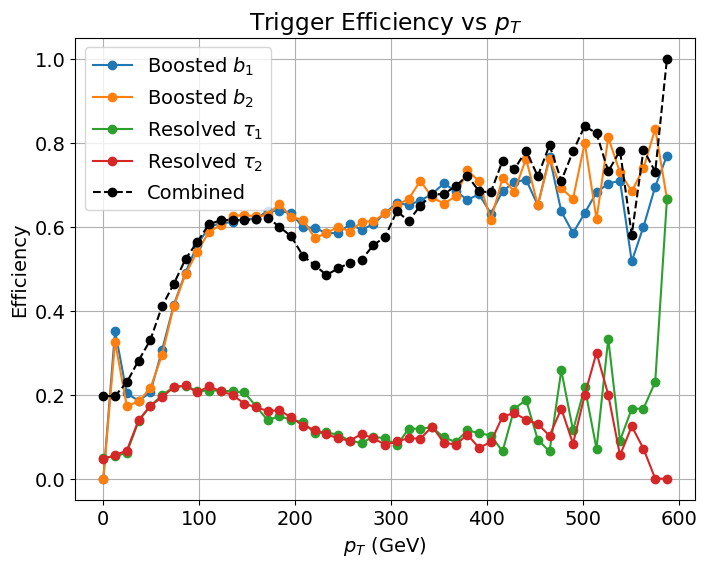

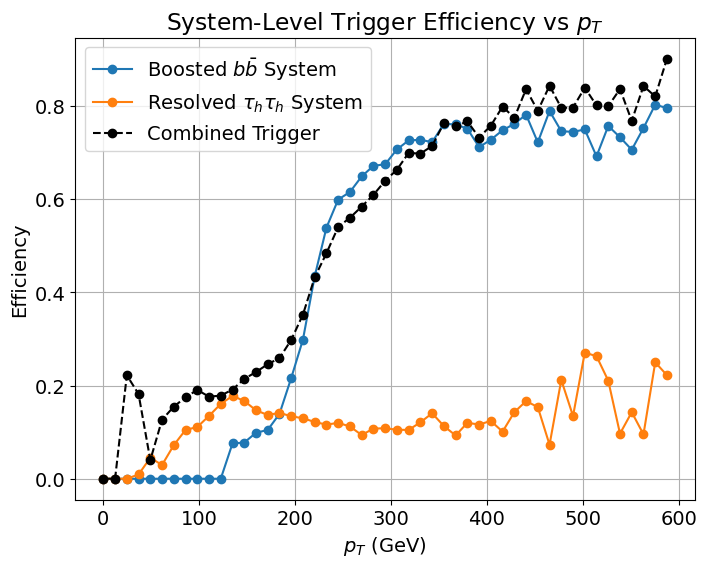

In [ ]:
bins = np.linspace(0, 600, 50)  # Example bin edges for pT

# pT data for Gen-level
pt_bb1 = df[("GenbbPt", 0)]  # Replace with Gen-level pT variable for b
pt_bb2 = df[("GenbbPt", 1)]
pt_Tau1 = df[("GenTauPt", 0)]  # Replace with Gen-level pT variable for TauTau
pt_Tau2 = df[("GenTauPt", 1)] 



# Digitize pT data (for binning)
digitized_bb1 = np.digitize(pt_bb1, bins)
digitized_bb2 = np.digitize(pt_bb2, bins)
digitized_Tau1 = np.digitize(pt_Tau1, bins)
digitized_Tau2 = np.digitize(pt_Tau2, bins)

# Combined system
pt_bb_system = np.sqrt(pt_bb1**2 + pt_bb2**2)
pt_TauTau_system = np.sqrt(pt_Tau1**2 + pt_Tau2**2)
digitized_bb_system = np.digitize(pt_bb_system, bins)
digitized_TauTau_system = np.digitize(pt_TauTau_system, bins)


boosted_bb1_efficiencies = [
    ((boosted_bb_trigger & boosted_gen_bb) & (digitized_bb1 == i)).sum() /
    (boosted_gen_bb & (digitized_bb1 == i)).sum()
    if (boosted_gen_bb & (digitized_bb1 == i)).sum() > 0 else 0
    for i in range(1, len(bins))
]

boosted_bb2_efficiencies = [
    ((boosted_bb_trigger & boosted_gen_bb) & (digitized_bb2 == i)).sum() /
    (boosted_gen_bb & (digitized_bb2 == i)).sum()
    if (boosted_gen_bb & (digitized_bb2 == i)).sum() > 0 else 0
    for i in range(1, len(bins))
]

# Efficiency for second tau
resolved_Tau1_efficiencies = [
    ((resolved_TauTau_trigger & resolved_gen_TauTau) & (digitized_Tau1 == i)).sum() /
    (resolved_gen_TauTau & (digitized_Tau1 == i)).sum()
    if (resolved_gen_TauTau & (digitized_Tau1 == i)).sum() > 0 else 0
    for i in range(1, len(bins))
]

resolved_Tau2_efficiencies = [
    ((resolved_TauTau_trigger & resolved_gen_TauTau) & (digitized_Tau2 == i)).sum() /
    (resolved_gen_TauTau & (digitized_Tau2 == i)).sum()
    if (resolved_gen_TauTau & (digitized_Tau2 == i)).sum() > 0 else 0
    for i in range(1, len(bins))
]


combined_trigger = boosted_bb_trigger | resolved_TauTau_trigger  # Both triggers activated
combined_gen = boosted_gen_bb | resolved_gen_TauTau  # Both gen-level conditions satisfied

combined_efficiencies = [
    ((combined_trigger & combined_gen) & (digitized_bb1 == i)).sum() /
    (combined_gen & (digitized_bb1 == i)).sum()
    if (combined_gen & (digitized_bb1 == i)).sum() > 0 else 0
    for i in range(1, len(bins))
]

plt.figure(figsize=(8, 6))

plt.plot(bins[:-1], boosted_bb1_efficiencies, label="Boosted $b_1$", marker='o')
plt.plot(bins[:-1], boosted_bb2_efficiencies, label="Boosted $b_2$", marker='o')

plt.plot(bins[:-1], resolved_Tau1_efficiencies, label="Resolved $\\tau_1$", marker='o')
plt.plot(bins[:-1], resolved_Tau2_efficiencies, label="Resolved $\\tau_2$", marker='o')

plt.plot(bins[:-1], combined_efficiencies, label="Combined", color = 'black', marker='o', linestyle='--')


plt.xlabel("$p_T$ (GeV)")
plt.ylabel("Efficiency")
plt.title("Trigger Efficiency vs $p_T$")
plt.legend()
plt.grid()
plt.show()



boosted_bb_system_efficiencies = [
    ((boosted_bb_trigger & boosted_gen_bb) & (digitized_bb_system == i)).sum() /
    (boosted_gen_bb & (digitized_bb_system == i)).sum()
    if (boosted_gen_bb & (digitized_bb_system == i)).sum() > 0 else 0
    for i in range(1, len(bins))
]

resolved_TauTau_system_efficiencies = [
    ((resolved_TauTau_trigger & resolved_gen_TauTau) & (digitized_TauTau_system == i)).sum() /
    (resolved_gen_TauTau & (digitized_TauTau_system == i)).sum()
    if (resolved_gen_TauTau & (digitized_TauTau_system == i)).sum() > 0 else 0
    for i in range(1, len(bins))
]

combined_system_efficiencies = [
    ((combined_trigger & combined_gen) & (digitized_bb_system == i)).sum() /
    (combined_gen & (digitized_bb_system == i)).sum()
    if (combined_gen & (digitized_bb_system == i)).sum() > 0 else 0
    for i in range(1, len(bins))
]

plt.figure(figsize=(8, 6))

plt.plot(bins[:-1], boosted_bb_system_efficiencies, label="Boosted $b\\bar{b}$ System", marker='o')
plt.plot(bins[:-1], resolved_TauTau_system_efficiencies, label="Resolved $\\tau_h\\tau_h$ System", marker='o')
plt.plot(bins[:-1], combined_system_efficiencies, label="Combined Trigger", color='black', marker='o', linestyle='--')

plt.xlabel("$p_T$ (GeV)")
plt.ylabel("Efficiency")
plt.title("System-Level Trigger Efficiency vs $p_T$")
plt.legend()
plt.grid()
plt.show()




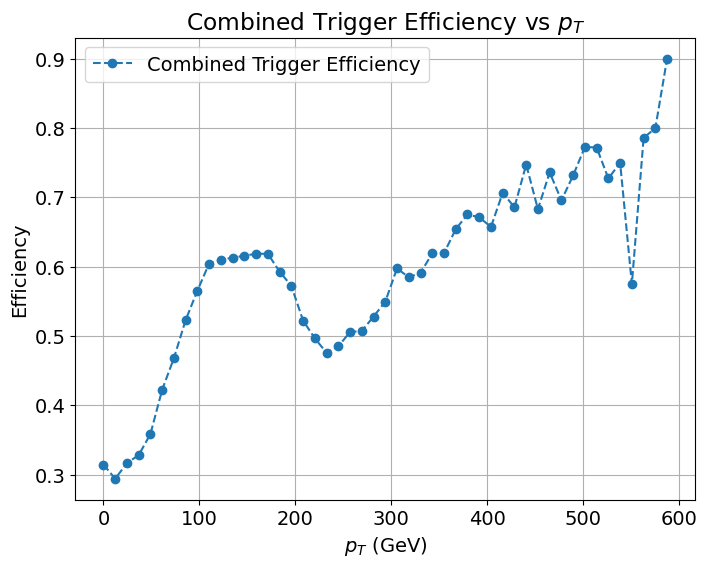

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(bins[:-1], combined_efficiencies, label="Combined Trigger Efficiency", marker='o', linestyle='--')

plt.xlabel("$p_T$ (GeV)")
plt.ylabel("Efficiency")
plt.title("Combined Trigger Efficiency vs $p_T$")
plt.legend()
plt.grid()
plt.show()